## Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import random
from itertools import combinations
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# For experiment analysis (keeping parallel to andrew's baseline)
import itertools
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

import exp as exptb

# For trying class balancing
from imblearn.over_sampling import SMOTE

# For counterfactual/recourse analysis
import dice_ml
import recourse_metrics
from raiutils.exceptions import UserConfigValidationException
import json
import ast

from multi_adversarial_debiasing import (
    MultiAdversarialMLP,
    evaluate_multi_adversarial_model,
    make_adversarial_loaders,
    prepare_smote_case_with_sensitive_labels,
    train_multi_adversarial_model,
)


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# "label" for comparability and comparability with andrew's encoded pipeline.
ENCODING_MODE = "label"   # onehot for future upgrade.
BATCH_SIZE = 512
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6


## Dataset Analysis & preprocessing

In [3]:
# Load and begin prepping strip search data
df = pd.read_csv('./datasets/torontostripsearch.csv', delimiter=',');df.head()

,Arrest_Year,Arrest_Month,EventID,ArrestID,PersonID,Perceived_Race,Sex,Age_group__at_arrest_,Youth_at_arrest__under_18_years,ArrestLocDiv,...,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative,SearchReason_CauseInjury,SearchReason_AssistEscape,SearchReason_PossessWeapons,SearchReason_PossessEvidence,ItemsFound,ObjectId
0,2020,July-Sept,1005907,6017884.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,1,NaN,NaN,NaN,NaN,NaN,1
1,2020,July-Sept,1014562,6056669.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,2
2,2020,Oct-Dec,1029922,6057065.0,326622,Unknown or Legacy,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,3
3,2021,Jan-Mar,1052190,6029059.0,327535,Black,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,4
4,2021,Jan-Mar,1015512,6040372.0,327535,South Asian,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,5


In [4]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}") #list unique valuyes for each column to get a sense of the data.
    print(df[col].unique())


Arrest_Year: 2
[2020 2021]
Arrest_Month: 4
['July-Sept' 'Oct-Dec' 'Jan-Mar' 'Apr-June']
EventID: 60003
[1005907 1014562 1029922 ... 1021067 1008998 1033395]
ArrestID: 64805
[6017884. 6056669. 6057065. ... 6064396. 6008662. 6032145.]
PersonID: 37347
[326622 327535 330778 ... 324057 331870 310583]
Perceived_Race: 8
['White' 'Unknown or Legacy' 'Black' 'South Asian' 'Indigenous'
 'Middle-Eastern' 'Latino' 'East/Southeast Asian' nan]
Sex: 3
['M' 'F' 'U']
Age_group__at_arrest_: 9
['Aged 35 to 44 years' 'Aged 25 to 34 years' 'Aged 45 to 54 years'
 'Aged 55 to 64 years' 'Aged 18 to 24 years' 'Aged 65 and older'
 'Aged 65 years and older' nan 'Aged 17 years and younger'
 'Aged 17 years and under']
Youth_at_arrest__under_18_years: 3
['Not a youth' 'Youth (aged 17 and younger)'
 'Youth (aged 17 years and under)']
ArrestLocDiv: 18
['54' 'XX' '42' '52' '14' '51' '53' '31' '11' '12' '13' '41' '22' '55'
 '43' '23' '33' '32']
StripSearch: 2
[0 1]
Booked: 2
[1 0]
Occurrence_Category: 31
['Assault & Ot

In [5]:

df['IsYouth'] = np.where(df['Youth_at_arrest__under_18_years'] == "Not a youth", 0, 1)
df = df.rename(columns={"Arrest_Month" : "Arrest_Quarter"})
df.drop(columns=df.columns.intersection(['SearchReason_CauseInjury', 'SearchReason_AssistEscape', 'SearchReason_PossessWeapons', 'Arrest_Year',
                                         'SearchReason_PossessEvidence', 'Youth_at_arrest__under_18_years', "_defensive_or_escape_risk",
                                         'ObjectId', 'EventID', 'ArrestID', 'PersonID', 'Booked', 'ItemsFound']), axis=1, inplace=True)

df.replace({'Perceived_Race': {np.nan: 'Unknown or Legacy'}}, inplace=True)

df = df.drop(df[df['Sex'] == 'U'].index)

df.dropna(how="any", inplace=True)
categorical_features = ['Perceived_Race', 'Sex', 'Occurrence_Category', 'ArrestLocDiv']
ordinal_features = ['Age_group__at_arrest_', 'Arrest_Quarter']
binary_features = ['IsYouth','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']


X = df.drop('StripSearch', axis=1)
X = X.drop('IsYouth', axis=1) # keep IsYouth and change how it affects the model in future work
y = df['StripSearch']

# Map the age groups to the specified values
custom_mapping = {
    'Aged 17 years and under': 0,
    'Aged 17 years and younger': 0,
    'Aged 18 to 24 years': 1,
    'Aged 25 to 34 years': 2,
    'Aged 35 to 44 years': 3,
    'Aged 45 to 54 years': 4,
    'Aged 55 to 64 years': 5,
    'Aged 65 and older': 6,
    'Aged 65 years and older': 6
}

quarter_mapping = {
"Jan-Mar" : 0,
"Apr-June" : 1,
"July-Sept" : 3,
"Oct-Dec" : 4
}

X['Age_group__at_arrest_'] = X['Age_group__at_arrest_'].map(custom_mapping)
X['Arrest_Quarter'] = X['Arrest_Quarter'].map(quarter_mapping)

# Store the reverse mappings for later use in analysis and visualization
rev_custom_mapping = {
    0 : 'Aged 17 years and younger',
    1 : 'Aged 18 to 24 years'      ,
    2 : 'Aged 25 to 34 years'      ,
    3 : 'Aged 35 to 44 years'      ,
    4 : 'Aged 45 to 54 years'      ,
    5 : 'Aged 55 to 64 years'      ,
    6 : 'Aged 65 and older'        
}

rev_quarter_mapping = {
    0 : "Jan-Mar"   ,
    1 : "Apr-June"  ,
    3 : "July-Sept" ,
    4 : "Oct-Dec"   
}

custom_encoders = {
    'Age_group__at_arrest_': rev_custom_mapping,
    'Arrest_Quarter': rev_quarter_mapping
}

In [6]:
X.head()

,Arrest_Quarter,Perceived_Race,Sex,Age_group__at_arrest_,ArrestLocDiv,Occurrence_Category,Actions_at_arrest___Concealed_i,Actions_at_arrest___Combative__,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative
0,3,White,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,1
1,3,White,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,0
2,4,Unknown or Legacy,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,0
3,0,Black,M,2,XX,Harassment/Threatening,0,0,0,0,0,0
4,0,South Asian,M,2,XX,FTA/FTC/Compliance Check/Parollee,0,0,0,0,0,0


In [7]:
# train/test split (same as Andrew)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build analysis copies with label encoding so slicing/explanation-table code still works
X_train_analysis = X_train.copy()
X_test_analysis = X_test.copy()

#Analysing which encoders we require for our Dataset and NN baseline
# 1. We have 4 categorical features: Perceived_Race, Sex, Occurrence_Category, ArrestLocDiv
# 2. We have 2 ordinal features: Age_group__at_arrest_, Arrest
# 3. We have 7 binary features: IsYouth, Actions_at_arrest___Concealed_i, Actions_at_arrest___Combative__, Actions_at_arrest___Resisted__d, Actions_at_arrest___Mental_inst, Actions_at_arrest___Assaulted_o, Actions_at_arrest___Cooperative

# Output directories for NN baseline artifacts
import os
OUT_BASE_DIR = "baseline_nn_output"
ENCODER_DIR = os.path.join(OUT_BASE_DIR, "encoder_tables")
FP_DIR = os.path.join(OUT_BASE_DIR, "fp_analysis")
DICE_DIR = os.path.join(OUT_BASE_DIR, "dice_cf")
RECOURSE_TEMP_DIR = os.path.join(OUT_BASE_DIR, "recourse_temp")
RECOURSE_TABLE_DIR = os.path.join(OUT_BASE_DIR, "recourse_tables")
for _d in [ENCODER_DIR, FP_DIR, DICE_DIR, RECOURSE_TEMP_DIR, RECOURSE_TABLE_DIR]:
    os.makedirs(_d, exist_ok=True)
print("Output dirs ready under:", OUT_BASE_DIR)



Output dirs ready under: baseline_nn_output


## Encoder Analysis
 1) categorical features (label encoder), ordinal features (ordinal encoder), binary features (passthrough)
 2) categorical features (one-hot), ordinal features (ordinal encoder), binary features (passthrough)
 3) categorical features (one-hot), ordinal features (ordinal encoder), binary features (one-hot )


In [8]:
# Base split copies (avoid accidental in-place mutation across cases)
X_train_base = X_train.copy(deep=True)
X_test_base = X_test.copy(deep=True)

# Labels once (shared across all cases)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)


def build_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_ord():
    # Safer than default: does not crash on unseen test categories
    return OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Keep only columns that are actually present in model frame (e.g., IsYouth may be dropped upstream)
cat_cols = [c for c in categorical_features if c in X_train_base.columns]
ord_cols = [c for c in ordinal_features if c in X_train_base.columns]
bin_cols = [c for c in binary_features if c in X_train_base.columns]

missing_cat = sorted(set(categorical_features) - set(cat_cols))
missing_ord = sorted(set(ordinal_features) - set(ord_cols))
missing_bin = sorted(set(binary_features) - set(bin_cols))

if missing_cat or missing_ord or missing_bin:
    print(" Skipped missing columns ->")
    print("  categorical:", missing_cat)
    print("  ordinal:", missing_ord)
    print("  binary:", missing_bin)

def run_case(case_name, preprocessor, Xtr, Xte, y_train_np, y_test_np, smote=False, random_state=42):
    
        
    Xtr_enc = preprocessor.fit_transform(Xtr)
    Xte_enc = preprocessor.transform(Xte)

    if smote:
        smote_sampler = SMOTE(random_state=random_state)
        Xtr_enc, y_train_np = smote_sampler.fit_resample(X=Xtr_enc, y=y_train_np)
        y_train_np = y_train_np.to_numpy(dtype=np.float32)

    scaler_local = StandardScaler()
    Xtr_np = scaler_local.fit_transform(Xtr_enc).astype(np.float32)
    Xte_np = scaler_local.transform(Xte_enc).astype(np.float32)

    print(case_name)
    print("  X_train:", Xtr_np.shape)
    print("  X_test :", Xte_np.shape)
    print("  Positive class ratio (train):", y_train_np.mean())
    
    
        

    return {
        "name": case_name,
        "preprocessor": preprocessor,
        "scaler": scaler_local,
        "X_train_np": Xtr_np,
        "X_test_np": Xte_np,
        "y_train_np": y_train_np,
        "y_test_np": y_test_np,
    }


# Case 1: encoded categorical + ordinal-encoded ordinal + binary passthrough
preprocessor_c1 = ColumnTransformer(
    transformers=[
        ("cat_ordenc", build_ord(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_pass", "passthrough", bin_cols),
    ],
    remainder="drop",
)

# Case 2: one-hot categorical + ordinal-encoded ordinal + binary passthrough
preprocessor_c2 = ColumnTransformer(
    transformers=[
        ("cat_ohe", build_ohe(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_pass", "passthrough", bin_cols),
    ],
    remainder="drop",
)

# Case 3: one-hot categorical + ordinal-encoded ordinal + one-hot binary
preprocessor_c3 = ColumnTransformer(
    transformers=[
        ("cat_ohe", build_ohe(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_ohe", build_ohe(), bin_cols),
    ],
    remainder="drop",
)

case1 = run_case(
    "Case 1 cat-encoded + ord-encoded + bin-passthrough",
    preprocessor_c1,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)
case2 = run_case(
    "Case 2 one-hot + ord-encoded + bin-passthrough",
    preprocessor_c2,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)
case3 = run_case(
    "Case 3 one-hot + ord-encoded + one-hot",
    preprocessor_c3,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)

case4 = run_case(
    "Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance",
    preprocessor_c3,
    X_train_base,
    X_test_base,
    y_train, 
    y_test_np,
    smote=True
)



 Skipped missing columns ->
  categorical: []
  ordinal: []
  binary: ['IsYouth']
Case 1 cat-encoded + ord-encoded + bin-passthrough
  X_train: (52062, 12)
  X_test : (13016, 12)
  Positive class ratio (train): 0.119857095
Case 2 one-hot + ord-encoded + bin-passthrough
  X_train: (52062, 67)
  X_test : (13016, 67)
  Positive class ratio (train): 0.119857095
Case 3 one-hot + ord-encoded + one-hot
  X_train: (52062, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.119857095
Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance
  X_train: (91644, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.5


In [9]:
# Train/val split for early stopping for each case (same as Andrew)
def train_val_split(X, y, val_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=val_size, random_state=random_state, stratify=y)

train_val_splits = {}
for case in [case1, case2, case4]:
    X_tr, X_val, y_tr, y_val = train_val_split(case["X_train_np"], case["y_train_np"])
    train_val_splits[case["name"]] = {
        "X_tr": X_tr,
        "y_tr": y_tr,
        "X_val": X_val,
        "y_val": y_val,}
    
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    case["train_loader"] = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    case["val_loader"] = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    

In [10]:
# Testing what happens when we applying smote to deal with the class imbalance
X_tr, X_val, y_tr, y_val = train_val_split(case3["X_train_np"], case3["y_train_np"])
print("Before applying smote to class imbalance")
print(f"num samples: {y_tr.shape[0]}, num class = 1 samples: {y_tr.sum()}, num class = 0 samples: {y_tr.shape[0] - y_tr.sum()}, ratio positive: {y_tr.sum()/y_tr.shape[0]:.2f}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tr, y_tr)

print("After applying smote to class imbalance")
print(f"num samples: {y_resampled.shape[0]}, num class = 1 samples: {y_resampled.sum()}, num class = 0 samples: {y_resampled.shape[0] - y_resampled.sum()}, ratio positive: {y_resampled.sum()/y_resampled.shape[0]:.2f}")
# included this as case 4 above

Before applying smote to class imbalance
num samples: 41649, num class = 1 samples: 4992.0, num class = 0 samples: 36657.0, ratio positive: 0.12
After applying smote to class imbalance
num samples: 73314, num class = 1 samples: 36657.0, num class = 0 samples: 36657.0, ratio positive: 0.50


### Neural Network

In [10]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())

        avg_val_loss = np.mean(val_losses)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
            
    if best_state is not None:
        model.load_state_dict(best_state)

### Test Set Evaluation

In [11]:
def label_false_positives(X_test, y_test, y_pred):
    fps = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 1 and y_truth[i[0]] == 0:
            fps[i[0]] = 1
    test_copy["targetcol"] = np.round(fps, 2)
    return test_copy

def label_false_negatives(X_test, y_test, y_pred):
    fns = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 0 and y_truth[i[0]] == 1:
            fns[i[0]] = 1
    test_copy["targetcol"] = np.round(fns, 2)
    return test_copy


def make_loaders(X_train_np, y_train_np, batch_size=512, seed=42, val_size=0.1):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_np, y_train_np, test_size=val_size, random_state=seed, stratify=y_train_np
    )
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def evaluate_model(model, X_test_np, y_test_np):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
        logits = model(x)            
        logits = logits.reshape(-1)    # robust for [N] or [N,1]
        probs = torch.sigmoid(logits).cpu().numpy()

    y_pred = (probs >= 0.5).astype(int)
    y_true = np.asarray(y_test_np).astype(int).reshape(-1)

    return {
        "y_pred": y_pred,
        "y_prob": probs,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, probs),
    }


In [18]:
results = {}
X_test_for_labels = X_test.copy().reset_index(drop=True)   # raw/readable frame
y_test_series = y_test.copy().reset_index(drop=True)       # for our FP/FN funcs

for case in [case1, case2, case3, case4]:
    print(f"\nTraining {case['name']}...")
    train_loader, val_loader = make_loaders(
        case["X_train_np"], case["y_train_np"], batch_size=BATCH_SIZE, seed=SEED
    )

    model = MLPBaseline(input_dim=case["X_train_np"].shape[1]).to(DEVICE)
    train_model(model, train_loader, val_loader)

    eval_out = evaluate_model(model, case["X_test_np"], case["y_test_np"])
    results[case["name"]] = {
        **eval_out,
        "model": model,
    }

    print(
        f"{case['name']} | Acc={eval_out['accuracy']:.4f} | "
        f"F1={eval_out['f1']:.4f} | ROC-AUC={eval_out['roc_auc']:.4f}"
    )

# metric table
metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)

# FP/FN labeled tables by case
fp_tables = {}
fn_tables = {}
for case_name, out in results.items():
    fp_tables[case_name] = label_false_positives(X_test_for_labels, y_test_series, out["y_pred"])
    fn_tables[case_name] = label_false_negatives(X_test_for_labels, y_test_series, out["y_pred"])
    print(case_name, "| FP:", int(fp_tables[case_name]["targetcol"].sum()),
          "| FN:", int(fn_tables[case_name]["targetcol"].sum()))



Training Case 1 cat-encoded + ord-encoded + bin-passthrough...
Epoch 1/40 - Train Loss: 0.3902 - Val Loss: 0.3448
Epoch 2/40 - Train Loss: 0.3433 - Val Loss: 0.3402
Epoch 3/40 - Train Loss: 0.3383 - Val Loss: 0.3374
Epoch 4/40 - Train Loss: 0.3350 - Val Loss: 0.3350
Epoch 5/40 - Train Loss: 0.3326 - Val Loss: 0.3325
Epoch 6/40 - Train Loss: 0.3297 - Val Loss: 0.3301
Epoch 7/40 - Train Loss: 0.3279 - Val Loss: 0.3284
Epoch 8/40 - Train Loss: 0.3254 - Val Loss: 0.3252
Epoch 9/40 - Train Loss: 0.3236 - Val Loss: 0.3247
Epoch 10/40 - Train Loss: 0.3229 - Val Loss: 0.3248
Epoch 11/40 - Train Loss: 0.3210 - Val Loss: 0.3223
Epoch 12/40 - Train Loss: 0.3195 - Val Loss: 0.3225
Epoch 13/40 - Train Loss: 0.3191 - Val Loss: 0.3239
Epoch 14/40 - Train Loss: 0.3192 - Val Loss: 0.3218
Epoch 15/40 - Train Loss: 0.3187 - Val Loss: 0.3209
Epoch 16/40 - Train Loss: 0.3177 - Val Loss: 0.3197
Epoch 17/40 - Train Loss: 0.3169 - Val Loss: 0.3214
Epoch 18/40 - Train Loss: 0.3152 - Val Loss: 0.3200
Epoch 19/

,case,accuracy,f1,roc_auc
2,Case 3 one-hot + ord-encoded + one-hot,0.900123,0.451014,0.896335
1,Case 2 one-hot + ord-encoded + bin-passthrough,0.901813,0.451502,0.896258
3,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,0.840811,0.518140,0.880672
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,0.884066,0.120117,0.806533


Case 1 cat-encoded + ord-encoded + bin-passthrough | FP: 52 | FN: 1457
Case 2 one-hot + ord-encoded + bin-passthrough | FP: 244 | FN: 1034
Case 3 one-hot + ord-encoded + one-hot | FP: 274 | FN: 1026
Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance | FP: 1626 | FN: 446


### Case 5: Multi-adversarial debiasing on top of the SMOTE baseline

- This is the in-processing debiasing variant for the NN. 
- Adapting Andrew's Case 4 "encoding + SMOTE setup". 
- Train the predictor against multiple adversaries for `Perceived_Race`, `Sex`, and the `Race x Sex` intersection.


In [ ]:


case5_name = "Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing"
case5_protected_cols = ["Perceived_Race", "Sex"]

case5 = prepare_smote_case_with_sensitive_labels(
    case_name=case5_name,
    preprocessor=preprocessor_c3,
    x_train_raw=X_train_base,
    x_test_raw=X_test_base,
    y_train=y_train,
    y_test=y_test,
    protected_cols=case5_protected_cols,
    random_state=SEED,
)

# Add an intersection adversary so the representation is discouraged from encoding
# both single-attribute and intersectional sensitive signals.
race_targets = case5["protected_targets"]["Perceived_Race"]
sex_targets = case5["protected_targets"]["Sex"]
sex_cardinality = len(case5["protected_classes"]["Sex"])
case5["protected_targets"]["Race_Sex_intersection"] = race_targets * sex_cardinality + sex_targets
case5["protected_classes"]["Race_Sex_intersection"] = [
    f"{race}|{sex}"
    for race in case5["protected_classes"]["Perceived_Race"]
    for sex in case5["protected_classes"]["Sex"]
]

train_loader_case5, val_loader_case5, case5_protected_order = make_adversarial_loaders(
    case5["X_train_np"],
    case5["y_train_np"],
    case5["protected_targets"],
    batch_size=BATCH_SIZE,
    seed=SEED,
    val_size=0.1,
)

case5_model = MultiAdversarialMLP(
    input_dim=case5["X_train_np"].shape[1],
    protected_output_dims={
        name: len(case5["protected_classes"][name])
        for name in case5_protected_order
    },
).to(DEVICE)

case5_history = train_multi_adversarial_model(
    case5_model,
    train_loader_case5,
    val_loader_case5,
    case5_protected_order,
    device=DEVICE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    adv_lambda=1.0,
    adv_weight=0.5,
)

case5_eval = evaluate_multi_adversarial_model(
    case5_model,
    case5["X_test_np"],
    case5["y_test_np"],
    DEVICE,
)
results[case5_name] = {
    **case5_eval,
    "model": case5_model,
    "history": case5_history,
}

fp_tables[case5_name] = label_false_positives(X_test_for_labels, y_test_series, case5_eval["y_pred"])
fn_tables[case5_name] = label_false_negatives(X_test_for_labels, y_test_series, case5_eval["y_pred"])

print(
    f"{case5_name} | Acc={case5_eval['accuracy']:.4f} | "
    f"F1={case5_eval['f1']:.4f} | ROC-AUC={case5_eval['roc_auc']:.4f}"
)
print(
    case5_name,
    "| FP:", int(fp_tables[case5_name]["targetcol"].sum()),
    "| FN:", int(fn_tables[case5_name]["targetcol"].sum()),
)

metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)



Epoch 1/40 | task_train=0.4460 | adv_train=4.3284 | task_val=0.3832 | adv_val=4.0637 | lambda=0.025
Epoch 2/40 | task_train=0.3828 | adv_train=4.0958 | task_val=0.3720 | adv_val=3.8168 | lambda=0.050
Epoch 3/40 | task_train=0.3680 | adv_train=3.9270 | task_val=0.3547 | adv_val=3.8933 | lambda=0.075
Epoch 4/40 | task_train=0.3562 | adv_train=3.9289 | task_val=0.3432 | adv_val=3.8065 | lambda=0.100
Epoch 5/40 | task_train=0.3473 | adv_train=3.9136 | task_val=0.3374 | adv_val=3.7961 | lambda=0.125
Epoch 6/40 | task_train=0.3416 | adv_train=3.9162 | task_val=0.3310 | adv_val=3.8942 | lambda=0.150
Epoch 7/40 | task_train=0.3341 | adv_train=3.9253 | task_val=0.3262 | adv_val=3.8774 | lambda=0.175
Epoch 8/40 | task_train=0.3296 | adv_train=3.9118 | task_val=0.3187 | adv_val=3.8402 | lambda=0.200
Epoch 9/40 | task_train=0.3237 | adv_train=3.9347 | task_val=0.3167 | adv_val=3.9126 | lambda=0.225
Epoch 10/40 | task_train=0.3218 | adv_train=3.9301 | task_val=0.3121 | adv_val=3.8733 | lambda=0.250

,case,accuracy,f1,roc_auc
2,Case 3 one-hot + ord-encoded + one-hot,0.900123,0.451014,0.896335
1,Case 2 one-hot + ord-encoded + bin-passthrough,0.901813,0.451502,0.896258
4,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,0.847111,0.521864,0.882396
3,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,0.840811,0.518140,0.880672
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,0.884066,0.120117,0.806533


### Disparity by Sex and Race (indepth case-wise analysis)

In [19]:
protected_cols = ["Perceived_Race", "Sex", "Race_Sex_intersection"]

y_true = y_test.reset_index(drop=True).astype(int)
X_grp = X_test.reset_index(drop=True).copy()
X_grp["Race_Sex_intersection"] = (
    X_grp["Perceived_Race"].astype(str) + " | " + X_grp["Sex"].astype(str)
)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def group_error_table(X_raw, y_true, y_pred, group_col):
    df = pd.DataFrame({
        "group": X_raw[group_col].reset_index(drop=True),
        "y_true": y_true.reset_index(drop=True).astype(int),
        "y_pred": pd.Series(y_pred).reset_index(drop=True).astype(int)
    })

    rows = []
    for g, part in df.groupby("group"):
        yt = part["y_true"].to_numpy()
        yp = part["y_pred"].to_numpy()

        tp = int(((yt == 1) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        n = len(part)

        tpr = safe_div(tp, tp + fn)
        fpr = safe_div(fp, fp + tn)
        fnr = safe_div(fn, tp + fn)
        sel = safe_div(tp + fp, n)

        rows.append({
            "group": g, "count": n, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "TPR": tpr, "FPR": fpr, "FNR": fnr, "SelectionRate": sel
        })

    out = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    return out

def disparity_summary(group_df, metrics=("TPR", "FPR", "FNR", "SelectionRate")):
    d = {}
    for m in metrics:
        vals = group_df[m].dropna()
        d[f"{m}_gap"] = (vals.max() - vals.min()) if len(vals) else np.nan
    # Equalized Odds-style scalar (smaller is better)
    d["EO_gap_max"] = np.nanmax([d["TPR_gap"], d["FPR_gap"]])
    return d

group_tables = {}
summary_rows = []

for case_name, out in results.items():
    y_pred = out["y_pred"]

    for col in protected_cols:
        gtab = group_error_table(X_grp, y_true, y_pred, col)
        group_tables[(case_name, col)] = gtab

        gaps = disparity_summary(gtab)
        summary_rows.append({
            "case": case_name,
            "attribute": col,
            "accuracy": out["accuracy"],
            "f1": out["f1"],
            "roc_auc": out["roc_auc"],
            **gaps
        })

# Detailed per-group tables
for (case_name, col), tbl in group_tables.items():
    print(f"\n=== {case_name} | {col} ===")
    display(tbl)

# Compact comparison table for decision
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["attribute", "EO_gap_max", "FNR_gap", "FPR_gap", "f1"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== Disparity Summary (lower gaps better) ===")
display(summary_df)

#Save this summary table and all the group tables for later analysis and visualization in the next notebook.
summary_df.to_csv(os.path.join(ENCODER_DIR, "disparity_summary.csv"), index=False)

for (case_name, col), tbl in group_tables.items():
    tbl.to_csv(os.path.join(ENCODER_DIR, f"group_table_{case_name}_{col}.csv"), index=False)



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Perceived_Race ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White,5501,53,4750,28,670,0.073306,0.005860,0.926694,0.014725
1,Black,3464,37,2958,17,452,0.075665,0.005714,0.924335,0.015589
2,Unknown or Legacy,1135,3,1025,2,105,0.027778,0.001947,0.972222,0.004405
3,East/Southeast Asian,839,4,774,1,60,0.062500,0.001290,0.937500,0.005959
4,South Asian,712,3,663,0,46,0.061224,0.000000,0.938776,0.004213
5,Middle-Eastern,623,0,575,1,47,0.000000,0.001736,1.000000,0.001605
6,Indigenous,392,2,335,1,54,0.035714,0.002976,0.964286,0.007653
7,Latino,350,1,324,2,23,0.041667,0.006135,0.958333,0.008571



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Sex ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,83,9150,38,1206,0.064391,0.004136,0.935609,0.011549
1,F,2539,20,2254,14,251,0.073801,0.006173,0.926199,0.013391



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Race_Sex_intersection ===


...

,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,945,7823,1365,344,0.733126,0.148563,0.266874,0.220483
1,F,2539,169,2007,261,102,0.623616,0.115079,0.376384,0.169358



=== Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance | Race_Sex_intersection ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White | M,4273,423,3112,608,130,0.764919,0.163441,0.235081,0.241282
1,Black | M,2864,334,1993,436,101,0.767816,0.179498,0.232184,0.268855
2,White | F,1228,112,892,166,58,0.658824,0.156900,0.341176,0.226384
3,Unknown or Legacy | M,936,59,731,112,34,0.634409,0.132859,0.365591,0.182692
4,East/Southeast Asian | M,695,32,585,52,26,0.551724,0.081633,0.448276,0.120863
5,South Asian | M,610,32,502,64,12,0.727273,0.113074,0.272727,0.157377
6,Black | F,600,29,482,64,25,0.537037,0.117216,0.462963,0.155000
7,Middle-Eastern | M,552,23,472,38,19,0.547619,0.074510,0.452381,0.110507
8,Latino | M,290,7,242,27,14,0.333333,0.100372,0.666667,0.117241
9,Indigenous | M,257,35,186,28,8,0.813953,0.130841,0.186047,0.245136



=== Disparity Summary (lower gaps better) ===


,case,attribute,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,Perceived_Race,0.884066,0.120117,0.806533,0.075665,0.006135,0.075665,0.013984,0.075665
1,Case 3 one-hot + ord-encoded + one-hot,Perceived_Race,0.900123,0.451014,0.896335,0.240502,0.024972,0.240502,0.064825,0.240502
2,Case 2 one-hot + ord-encoded + bin-passthrough,Perceived_Race,0.901813,0.451502,0.896258,0.297619,0.017146,0.297619,0.063878,0.297619
3,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840811,0.518140,0.880672,0.375000,0.095809,0.375000,0.146277,0.375000
4,Case 1 cat-encoded + ord-encoded + bin-passthr...,Race_Sex_intersection,0.884066,0.120117,0.806533,0.333333,0.010397,0.333333,0.020358,0.333333
5,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840811,0.518140,0.880672,0.647287,0.179498,0.647287,0.235521,0.647287
6,Case 2 one-hot + ord-encoded + bin-passthrough,Race_Sex_intersection,0.901813,0.451502,0.896258,0.666667,0.027995,0.666667,0.105896,0.666667
7,Case 3 one-hot + ord-encoded + one-hot,Race_Sex_intersection,0.900123,0.451014,0.896335,0.666667,0.036641,0.666667,0.105058,0.666667
8,Case 1 cat-encoded + ord-encoded + bin-passthr...,Sex,0.884066,0.120117,0.806533,0.009410,0.002037,0.009410,0.001842,0.009410
9,Case 2 one-hot + ord-encoded + bin-passthrough,Sex,0.901813,0.451502,0.896258,0.046336,0.001268,0.046336,0.011353,0.046336


1. Case 4 is the new NN baseline for debiasing work.
- Andrew's SMOTE update materially improves recall/F1 versus Cases 1-3, even though accuracy drops.
- That is the correct baseline to compare against for any in-processing debiasing method.

2. Case 5 is the in-processing debiased variant.
- It keeps the Case 4 encoding + SMOTE pipeline, then adds multi-adversarial training on `Perceived_Race`, `Sex`, and the `Race x Sex` intersection.
- Read Case 5 against Case 4 in the disparity summary table; that is the main fairness comparison for the project write-up.

3. Practical interpretation of the tradeoff.
- Case 5 lowers the disparity gaps with only a small utility drop, it is the better project model.
- Some protected attribute gap gets worse so we can tune the adversarial weight or group-aware reweighting instead of reverting to the pre-SMOTE cases.


## Explaination Tables

### Case3 - Og Baseline

In [16]:
case3_name = next(k for k in results.keys() if k.startswith("Case 3"))
case_map = {c["name"]: c for c in [case1, case2, case3]}

case3_out = results[case3_name]          # contains y_pred, y_prob, metrics, model
case3_cfg = case_map[case3_name]         # contains preprocessor, scaler, X/y arrays

model_case3 = case3_out["model"]
y_pred_case3 = case3_out["y_pred"]

preprocessor_case3 = case3_cfg["preprocessor"]
scaler_case3 = case3_cfg["scaler"]

X_test_case3_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case3 = y_test.copy().reset_index(drop=True).astype(int)

print(case3_name)
print("Accuracy:", case3_out["accuracy"], "| F1:", case3_out["f1"], "| ROC-AUC:", case3_out["roc_auc"])
print("FP:", int(((y_pred_case3 == 1) & (y_test_case3.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case3 == 0) & (y_test_case3.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]

#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case3 = label_false_positives(X_test_exp, y_test_case3, y_pred_case3)
temp_case3_fp_path = os.path.join(FP_DIR, "temp_case3_fp.csv")
target_case3_fp_path = os.path.join(FP_DIR, "target_case3_fp.csv")
x_res_fp_case3[exp_table_cols].to_csv(temp_case3_fp_path, index=False)
pd.DataFrame().to_csv(target_case3_fp_path, index=False)

res_fp_case3 = exp_mod.calculate_table(
    target_case3_fp_path, temp_case3_fp_path, target_case3_fp_path, min_support_param=min_sup
)

fp_exp_case3 = pd.read_csv(res_fp_case3, sep=";")
# sort in descending order of targetcol 
sorted_fp_case3 = fp_exp_case3.sort_values(by=["targetcol"], ascending=[False])
print("case 3")
sorted_fp_case3

Case 3 one-hot + ord-encoded + one-hot
Accuracy: 0.9001229256299939 | F1: 0.45101351351351354 | ROC-AUC: 0.8963347221476149
FP: 274
FN: 1026
Compiling with commands:  ['g++', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Explanations.cpp', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Lighthouse.cpp', '-o', 'program']
Arguments to the program: baseline_nn_output\fp_analysis\target_case3_fp.csv baseline_nn_output\fp_analysis\temp_case3_fp.csv 3 15 0 baseline_nn_output\fp_analysis\target_case3_fp.csv 0.1
Time: 0:00:09.737387
case 3


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
1,0,*,*,0.030,3464
2,*,*,2,0.025,4237
12,*,1,2,0.025,3378
3,7,*,3,0.024,1511
4,*,1,1,0.024,1598
7,7,*,2,0.024,1687
6,*,1,3,0.023,2601
8,*,*,3,0.022,3210
11,*,*,1,0.022,2012
0,*,*,*,0.021,13016


### Case4:  SMOTE-NN Baseline

In [17]:
case4_name = next(k for k in results.keys() if k.startswith("Case 4"))
case_map = {c["name"]: c for c in [case1, case2, case3, case4]}

case4_out = results[case4_name]          # contains y_pred, y_prob, metrics, model
case4_cfg = case_map[case4_name]         # contains preprocessor, scaler, X/y arrays

model_case4 = case4_out["model"]
y_pred_case4 = case4_out["y_pred"]

preprocessor_case4 = case4_cfg["preprocessor"]
scaler_case4 = case4_cfg["scaler"]

X_test_case4_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case4 = y_test.copy().reset_index(drop=True).astype(int)

print(case4_name)
print("Accuracy:", case4_out["accuracy"], "| F1:", case4_out["f1"], "| ROC-AUC:", case4_out["roc_auc"])
print("FP:", int(((y_pred_case4 == 1) & (y_test_case4.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case4 == 0) & (y_test_case4.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case4 = label_false_positives(X_test_exp, y_test_case4, y_pred_case4)
temp_case4_fp_path = os.path.join(FP_DIR, "temp_case4_fp.csv")
target_case4_fp_path = os.path.join(FP_DIR, "target_case4_fp.csv")
x_res_fp_case4[exp_table_cols].to_csv(temp_case4_fp_path, index=False)
pd.DataFrame().to_csv(target_case4_fp_path, index=False)

res_fp_case4 = exp_mod.calculate_table(
    target_case4_fp_path, temp_case4_fp_path, target_case4_fp_path, min_support_param=min_sup
)
fp_exp_case4 = pd.read_csv(res_fp_case4, sep=";")
# sort in descending order of targetcol 
sorted_fp_case4 = fp_exp_case4.sort_values(by=["targetcol"], ascending=[False])
print("case 4")
sorted_fp_case4

Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance
Accuracy: 0.8408113091579594 | F1: 0.5181395348837209 | ROC-AUC: 0.8806724558175762
FP: 1626
FN: 446
Compiling with commands:  ['g++', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Explanations.cpp', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Lighthouse.cpp', '-o', 'program']
Arguments to the program: baseline_nn_output\fp_analysis\target_case4_fp.csv baseline_nn_output\fp_analysis\temp_case4_fp.csv 3 15 0 baseline_nn_output\fp_analysis\target_case4_fp.csv 0.1
Time: 0:00:09.516310
case 4


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
1,7,*,2,0.179,1687
2,0,1,*,0.152,2864
6,*,1,2,0.151,3378
13,*,1,1,0.148,1598
7,*,*,2,0.147,4237
9,7,*,3,0.146,1511
10,0,*,*,0.144,3464
3,7,*,*,0.141,5501
4,*,*,1,0.141,2012
5,*,1,3,0.134,2601


### Case5: In-processing Debiasing (Multi-Adversarial)

In [18]:
case5_name = next(k for k in results.keys() if k.startswith("Case 5"))
case_map = {c["name"]: c for c in [case1, case2, case3, case4, case5]}

case5_out = results[case5_name]          # contains y_pred, y_prob, metrics, model
case5_cfg = case_map[case5_name]         # contains preprocessor, scaler, X/y arrays

model_case5 = case5_out["model"]
y_pred_case5 = case5_out["y_pred"]

preprocessor_case5 = case5_cfg["preprocessor"]
scaler_case5 = case5_cfg["scaler"]

X_test_case5_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case5 = y_test.copy().reset_index(drop=True).astype(int)

print(case5_name)
print("Accuracy:", case5_out["accuracy"], "| F1:", case5_out["f1"], "| ROC-AUC:", case5_out["roc_auc"])
print("FP:", int(((y_pred_case5 == 1) & (y_test_case5.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case5 == 0) & (y_test_case5.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case5 = label_false_positives(X_test_exp, y_test_case5, y_pred_case5)
temp_case5_fp_path = os.path.join(FP_DIR, "temp_case5_fp.csv")
target_case5_fp_path = os.path.join(FP_DIR, "target_case5_fp.csv")
x_res_fp_case5[exp_table_cols].to_csv(temp_case5_fp_path, index=False)
pd.DataFrame().to_csv(target_case5_fp_path, index=False)

res_fp_case5 = exp_mod.calculate_table(
    target_case5_fp_path, temp_case5_fp_path, target_case5_fp_path, min_support_param=min_sup
)
fp_exp_case5 = pd.read_csv(res_fp_case5, sep=";")
# sort in descending order of targetcol 
sorted_fp_case5 = fp_exp_case5.sort_values(by=["targetcol"], ascending=[False])
print("case 5")
sorted_fp_case5

Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing
Accuracy: 0.8471112476951445 | F1: 0.5218644882268141 | ROC-AUC: 0.8823961075150408
FP: 1516
FN: 474
Compiling with commands:  ['g++', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Explanations.cpp', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Lighthouse.cpp', '-o', 'program']
Arguments to the program: baseline_nn_output\fp_analysis\target_case5_fp.csv baseline_nn_output\fp_analysis\temp_case5_fp.csv 3 15 0 baseline_nn_output\fp_analysis\target_case5_fp.csv 0.1
Time: 0:00:09.356911
case 5


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
4,7,*,2,0.153,1687
8,*,1,1,0.140,1598
1,*,*,2,0.139,4237
12,*,1,2,0.138,3378
2,*,*,1,0.136,2012
7,7,*,3,0.122,1511
9,0,1,*,0.119,2864
6,*,1,3,0.118,2601
10,0,*,*,0.117,3464
0,*,*,*,0.116,13016


### Baseline (before) v/s (after) Multi-adversarial Debiased NN

Case 4 vs Case 5 false-positive subgroup rates (outer join, so unique subgroups are kept; NA means the pattern was not returned in that case's explanation table)


,subgroup,present_case4,present_case5,support_case4,support_case5,fp_rate_case4,fp_rate_case5,fp_rate_delta
11,Black | M | *,True,True,2864.0,2864.0,0.152,0.119,-0.033
10,Black | * | *,True,True,3464.0,3464.0,0.144,0.117,-0.027
13,White | * | Aged 25 to 34 years,True,True,1687.0,1687.0,0.179,0.153,-0.026
14,White | * | Aged 35 to 44 years,True,True,1511.0,1511.0,0.146,0.122,-0.024
9,* | M | Aged 45 to 54 years,True,True,1479.0,1479.0,0.110,0.090,-0.020
8,* | M | Aged 35 to 44 years,True,True,2601.0,2601.0,0.134,0.118,-0.016
3,* | * | Aged 35 to 44 years,True,True,3210.0,3210.0,0.129,0.116,-0.013
7,* | M | Aged 25 to 34 years,True,True,3378.0,3378.0,0.151,0.138,-0.013
0,* | * | *,True,True,13016.0,13016.0,0.125,0.116,-0.009
2,* | * | Aged 25 to 34 years,True,True,4237.0,4237.0,0.147,0.139,-0.008


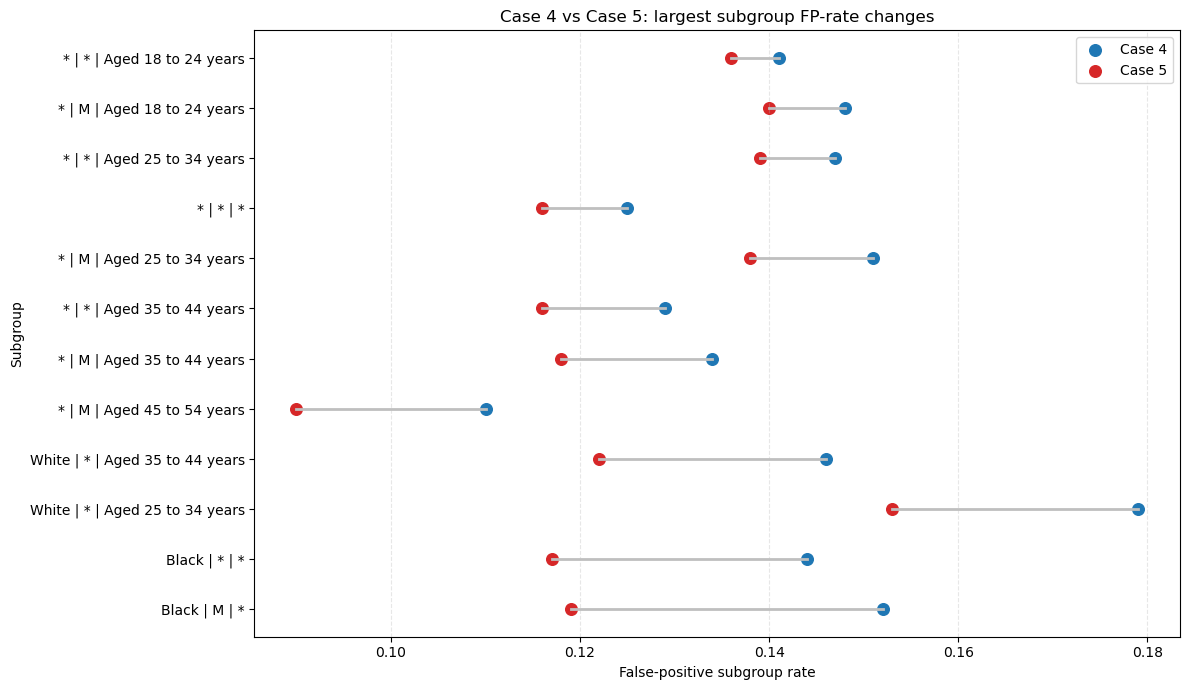

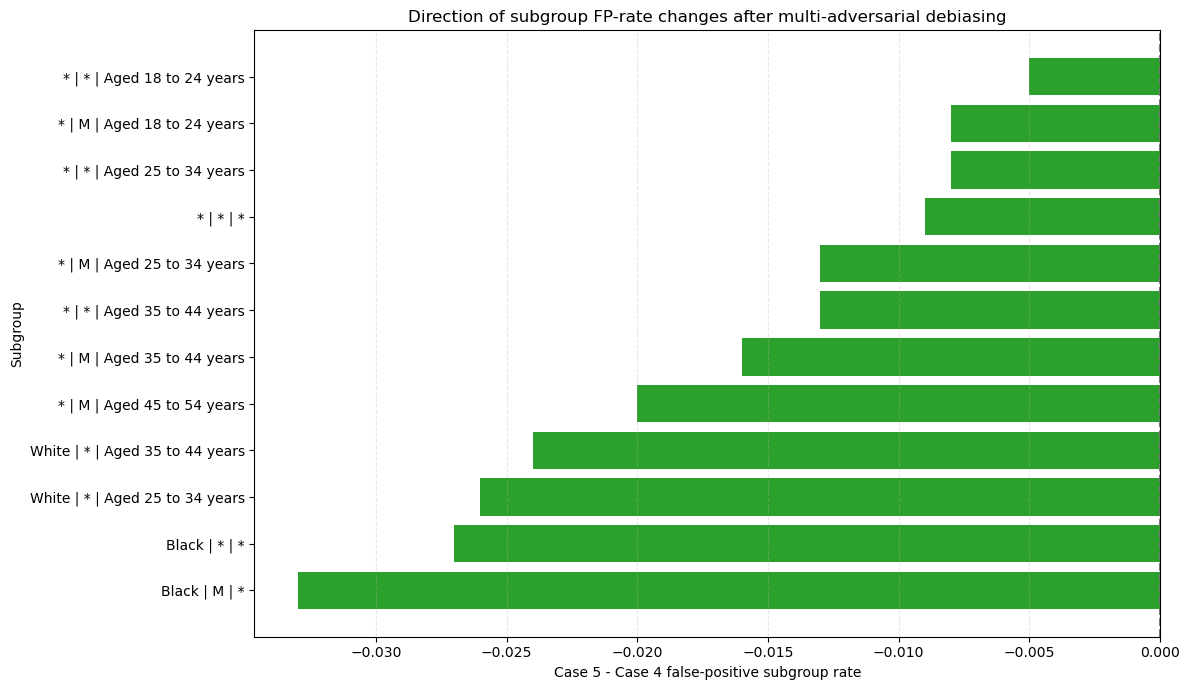

Case 4 vs Case 5 fairness summary


,case,attribute,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840811,0.518140,0.880672,0.375000,0.095809,0.375000,0.146277,0.375000
1,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.847111,0.521864,0.882396,0.244048,0.067580,0.244048,0.082320,0.244048
2,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840811,0.518140,0.880672,0.647287,0.179498,0.647287,0.235521,0.647287
3,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.847111,0.521864,0.882396,0.600000,0.080330,0.600000,0.137078,0.600000
4,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Sex,0.840811,0.518140,0.880672,0.109510,0.033484,0.109510,0.051125,0.109510
5,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Sex,0.847111,0.521864,0.882396,0.029732,0.007218,0.029732,0.018870,0.029732


Race-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
1,Black,3464,0.742331,0.672802,-0.069530,0.168067,0.136471,-0.031597,0.257669,0.327198,0.069530
3,East/Southeast Asian,839,0.515625,0.609375,0.093750,0.072258,0.098065,0.025806,0.484375,0.390625,-0.093750
6,Indigenous,392,0.750000,0.785714,0.035714,0.110119,0.125000,0.014881,0.250000,0.214286,-0.035714
7,Latino,350,0.375000,0.541667,0.166667,0.082822,0.165644,0.082822,0.625000,0.458333,-0.166667
5,Middle-Eastern,623,0.531915,0.553191,0.021277,0.074653,0.107639,0.032986,0.468085,0.446809,-0.021277
4,South Asian,712,0.734694,0.775510,0.040816,0.101056,0.125189,0.024133,0.265306,0.224490,-0.040816
2,Unknown or Legacy,1135,0.657407,0.675926,0.018519,0.118793,0.143135,0.024343,0.342593,0.324074,-0.018519
0,White,5501,0.739972,0.724758,-0.015214,0.161992,0.135203,-0.026789,0.260028,0.275242,0.015214


Sex-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
1,F,2539,0.623616,0.671587,0.047970,0.115079,0.126543,0.011464,0.376384,0.328413,-0.047970
0,M,10477,0.733126,0.701319,-0.031808,0.148563,0.133761,-0.014802,0.266874,0.298681,0.031808


Intersection-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
0,White | M,4273,0.764919,0.737794,-0.027125,0.163441,0.132527,-0.030914,0.235081,0.262206,0.027125
1,Black | M,2864,0.767816,0.680460,-0.087356,0.179498,0.140387,-0.039111,0.232184,0.319540,0.087356
2,White | F,1228,0.658824,0.682353,0.023529,0.156900,0.144612,-0.012287,0.341176,0.317647,-0.023529
3,Unknown or Legacy | M,936,0.634409,0.655914,0.021505,0.132859,0.155397,0.022539,0.365591,0.344086,-0.021505
4,East/Southeast Asian | M,695,0.551724,0.620690,0.068966,0.081633,0.100471,0.018838,0.448276,0.379310,-0.068966
5,South Asian | M,610,0.727273,0.750000,0.022727,0.113074,0.127208,0.014134,0.272727,0.250000,-0.022727
6,Black | F,600,0.537037,0.611111,0.074074,0.117216,0.119048,0.001832,0.462963,0.388889,-0.074074
7,Middle-Eastern | M,552,0.547619,0.571429,0.023810,0.074510,0.109804,0.035294,0.452381,0.428571,-0.023810
8,Latino | M,290,0.333333,0.523810,0.190476,0.100372,0.167286,0.066914,0.666667,0.476190,-0.190476
9,Indigenous | M,257,0.813953,0.813953,0.000000,0.130841,0.126168,-0.004673,0.186047,0.186047,0.000000


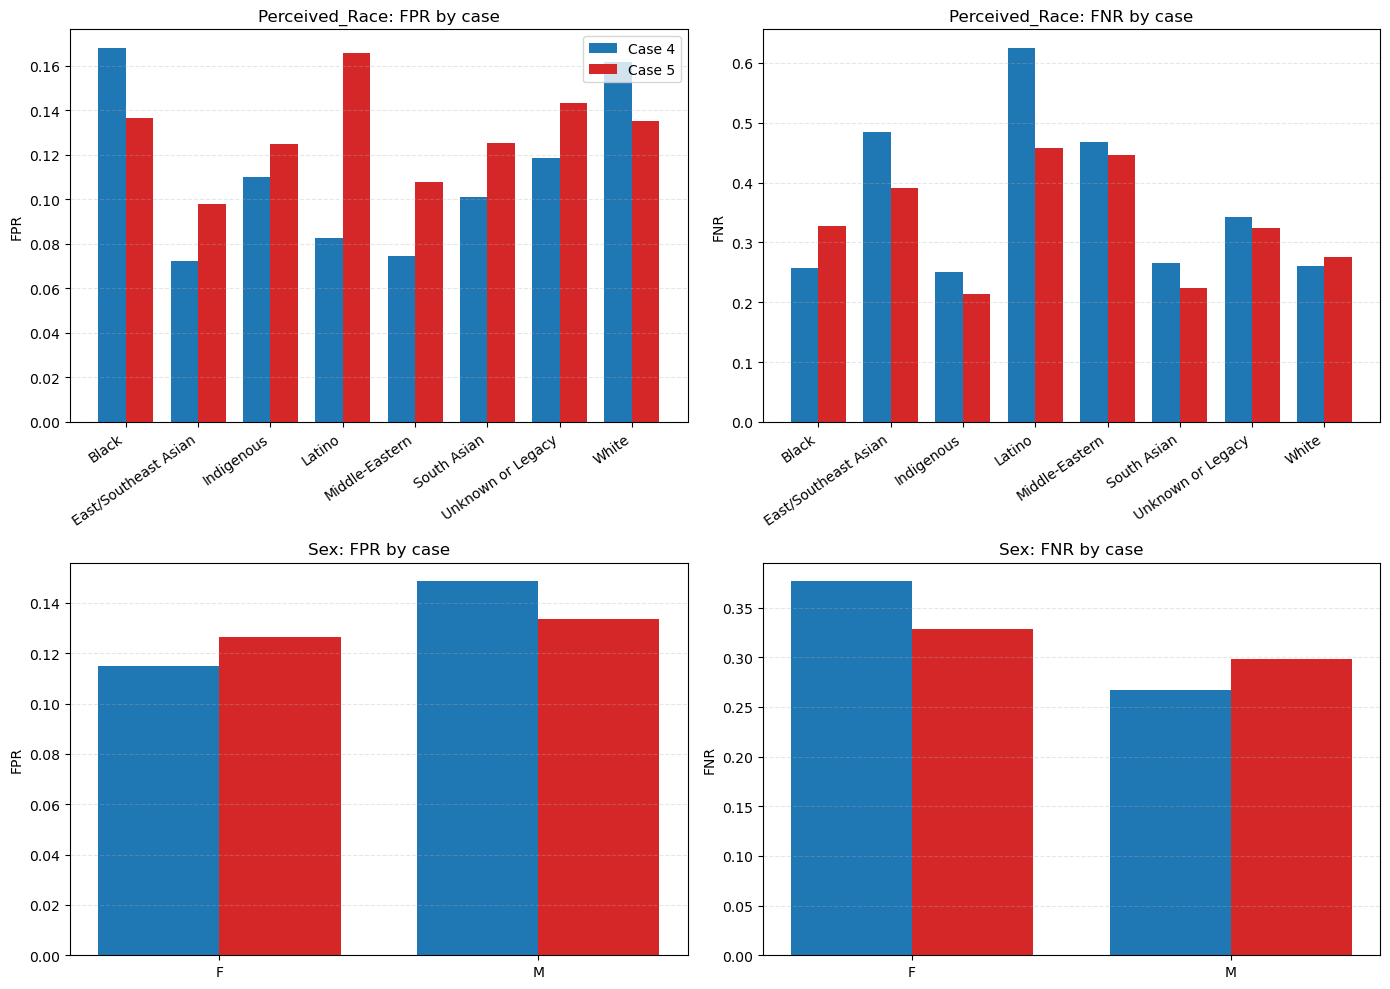

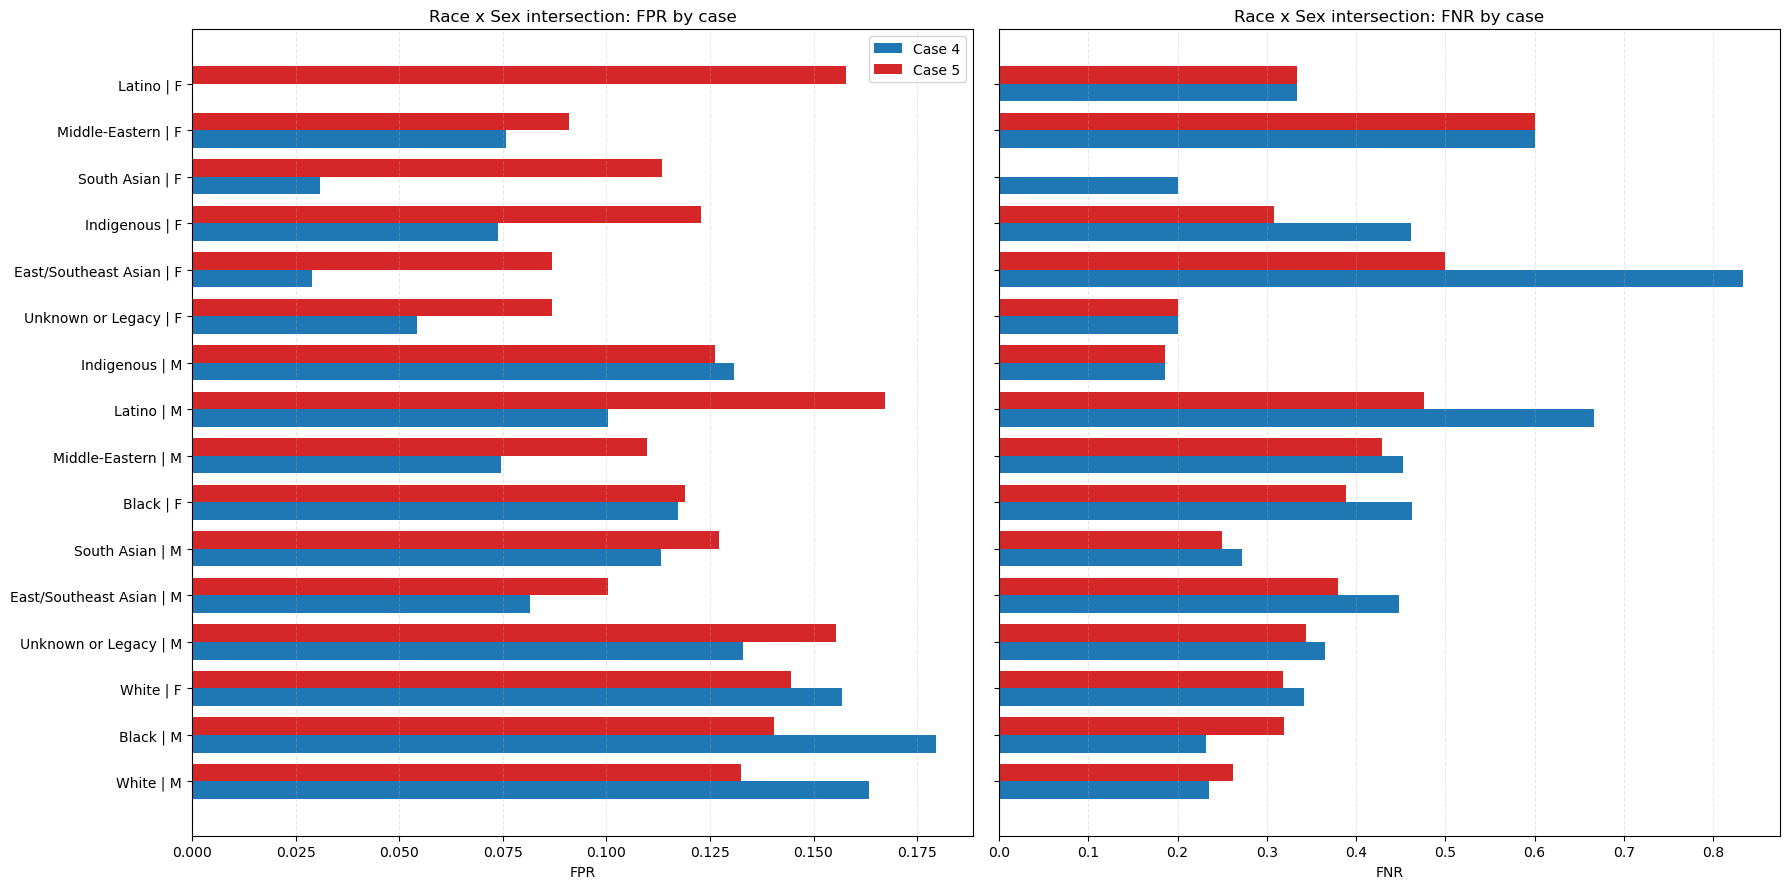

In [19]:
def decode_exp_table_labels(df_in, encoders_map, custom_map=None):
    out = df_in.copy()
    custom_map = custom_map or {}

    for col, le in encoders_map.items():
        if col not in out.columns:
            continue
        inv = {i: v for i, v in enumerate(le.classes_)}

        def decode_value(x):
            if pd.isna(x) or x == "*":
                return x
            try:
                return inv.get(int(float(x)), x)
            except (ValueError, TypeError):
                return x

        out[col] = out[col].apply(decode_value)

    for col, mapping in custom_map.items():
        if col not in out.columns:
            continue

        def decode_custom_value(x):
            if pd.isna(x) or x == "*":
                return x
            try:
                return mapping.get(int(float(x)), x)
            except (ValueError, TypeError):
                return x

        out[col] = out[col].apply(decode_custom_value)

    return out

def pretty_subgroup_label(row):
    return f"{row['Perceived_Race']} | {row['Sex']} | {row['Age_group__at_arrest_']}"

comparison_fp = sorted_fp_case4.merge(
    sorted_fp_case5,
    on=group_cols,
    how="outer",
    suffixes=("_case4", "_case5")
)
comparison_fp["present_case4"] = comparison_fp["support_case4"].notna()
comparison_fp["present_case5"] = comparison_fp["support_case5"].notna()
comparison_fp["fp_rate_delta"] = comparison_fp["targetcol_case5"] - comparison_fp["targetcol_case4"]
comparison_fp["abs_fp_rate_delta"] = comparison_fp["fp_rate_delta"].abs()
comparison_fp = comparison_fp.sort_values(
    by=["abs_fp_rate_delta", "support_case5", "support_case4"],
    ascending=[False, False, False],
    na_position="last"
)

comparison_fp_pretty = decode_exp_table_labels(comparison_fp, encoders, custom_encoders)
comparison_fp_pretty = comparison_fp_pretty.rename(columns={
    "targetcol_case4": "fp_rate_case4",
    "targetcol_case5": "fp_rate_case5",
})
comparison_fp_pretty["subgroup"] = comparison_fp_pretty.apply(pretty_subgroup_label, axis=1)

print("Case 4 vs Case 5 false-positive subgroup rates (outer join, so unique subgroups are kept; NA means the pattern was not returned in that case's explanation table)")
display(comparison_fp_pretty[["subgroup", "present_case4", "present_case5", "support_case4", "support_case5", "fp_rate_case4", "fp_rate_case5", "fp_rate_delta"]])

comparison_fp_overlap = comparison_fp_pretty[
    comparison_fp_pretty["present_case4"] & comparison_fp_pretty["present_case5"]
].copy()
top_delta = comparison_fp_overlap.sort_values("abs_fp_rate_delta", ascending=False).head(12).copy()
top_delta = top_delta.sort_values("fp_rate_delta")

plt.figure(figsize=(12, 7))
for _, row in top_delta.iterrows():
    plt.plot([row['fp_rate_case4'], row['fp_rate_case5']], [row['subgroup'], row['subgroup']], color='0.75', linewidth=2)
plt.scatter(top_delta['fp_rate_case4'], top_delta['subgroup'], color='#1f77b4', s=70, label='Case 4')
plt.scatter(top_delta['fp_rate_case5'], top_delta['subgroup'], color='#d62728', s=70, label='Case 5')
plt.xlabel('False-positive subgroup rate')
plt.ylabel('Subgroup')
plt.title('Case 4 vs Case 5: largest subgroup FP-rate changes')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
bar_colors = ['#d62728' if x > 0 else '#2ca02c' for x in top_delta['fp_rate_delta']]
plt.barh(top_delta['subgroup'], top_delta['fp_rate_delta'], color=bar_colors)
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Case 5 - Case 4 false-positive subgroup rate')
plt.ylabel('Subgroup')
plt.title('Direction of subgroup FP-rate changes after multi-adversarial debiasing')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Direct protected-attribute comparison from the readable group tables
def compare_group_metric(case4_tbl, case5_tbl):
    merged = case4_tbl.merge(case5_tbl, on='group', suffixes=('_case4', '_case5'))
    for metric in ['count', 'TPR', 'FPR', 'FNR', 'SelectionRate']:
        merged[f'{metric}_delta'] = merged[f'{metric}_case5'] - merged[f'{metric}_case4']
    return merged

case45_summary = summary_df[summary_df['case'].isin([case4_name, case5_name])].copy()
case45_summary = case45_summary.sort_values(['attribute', 'case']).reset_index(drop=True)
print('Case 4 vs Case 5 fairness summary')
display(case45_summary[['case', 'attribute', 'accuracy', 'f1', 'roc_auc', 'TPR_gap', 'FPR_gap', 'FNR_gap', 'SelectionRate_gap', 'EO_gap_max']])

race_compare = compare_group_metric(group_tables[(case4_name, 'Perceived_Race')], group_tables[(case5_name, 'Perceived_Race')])
sex_compare = compare_group_metric(group_tables[(case4_name, 'Sex')], group_tables[(case5_name, 'Sex')])
intersection_compare = compare_group_metric(group_tables[(case4_name, 'Race_Sex_intersection')], group_tables[(case5_name, 'Race_Sex_intersection')])

print('Race-level Case 4 vs Case 5 comparison')
display(race_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('group'))
print('Sex-level Case 4 vs Case 5 comparison')
display(sex_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('group'))
print('Intersection-level Case 4 vs Case 5 comparison')
display(intersection_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('count_case4', ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
race_plot = race_compare.sort_values('group').copy()
sex_plot = sex_compare.sort_values('group').copy()
race_idx = np.arange(len(race_plot))
sex_idx = np.arange(len(sex_plot))
width = 0.38

axes[0, 0].bar(race_idx - width/2, race_plot['FPR_case4'], width, label='Case 4', color='#1f77b4')
axes[0, 0].bar(race_idx + width/2, race_plot['FPR_case5'], width, label='Case 5', color='#d62728')
axes[0, 0].set_title('Perceived_Race: FPR by case')
axes[0, 0].set_xticks(race_idx)
axes[0, 0].set_xticklabels(race_plot['group'], rotation=35, ha='right')
axes[0, 0].set_ylabel('FPR')
axes[0, 0].legend()

axes[0, 1].bar(race_idx - width/2, race_plot['FNR_case4'], width, label='Case 4', color='#1f77b4')
axes[0, 1].bar(race_idx + width/2, race_plot['FNR_case5'], width, label='Case 5', color='#d62728')
axes[0, 1].set_title('Perceived_Race: FNR by case')
axes[0, 1].set_xticks(race_idx)
axes[0, 1].set_xticklabels(race_plot['group'], rotation=35, ha='right')
axes[0, 1].set_ylabel('FNR')

axes[1, 0].bar(sex_idx - width/2, sex_plot['FPR_case4'], width, label='Case 4', color='#1f77b4')
axes[1, 0].bar(sex_idx + width/2, sex_plot['FPR_case5'], width, label='Case 5', color='#d62728')
axes[1, 0].set_title('Sex: FPR by case')
axes[1, 0].set_xticks(sex_idx)
axes[1, 0].set_xticklabels(sex_plot['group'])
axes[1, 0].set_ylabel('FPR')

axes[1, 1].bar(sex_idx - width/2, sex_plot['FNR_case4'], width, label='Case 4', color='#1f77b4')
axes[1, 1].bar(sex_idx + width/2, sex_plot['FNR_case5'], width, label='Case 5', color='#d62728')
axes[1, 1].set_title('Sex: FNR by case')
axes[1, 1].set_xticks(sex_idx)
axes[1, 1].set_xticklabels(sex_plot['group'])
axes[1, 1].set_ylabel('FNR')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

intersection_plot = intersection_compare.sort_values('count_case4', ascending=False).copy()
intersection_y = np.arange(len(intersection_plot))
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

axes[0].barh(intersection_y - width/2, intersection_plot['FPR_case4'], height=width, color='#1f77b4', label='Case 4')
axes[0].barh(intersection_y + width/2, intersection_plot['FPR_case5'], height=width, color='#d62728', label='Case 5')
axes[0].set_title('Race x Sex intersection: FPR by case')
axes[0].set_yticks(intersection_y)
axes[0].set_yticklabels(intersection_plot['group'])
axes[0].set_xlabel('FPR')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].legend()

axes[1].barh(intersection_y - width/2, intersection_plot['FNR_case4'], height=width, color='#1f77b4', label='Case 4')
axes[1].barh(intersection_y + width/2, intersection_plot['FNR_case5'], height=width, color='#d62728', label='Case 5')
axes[1].set_title('Race x Sex intersection: FNR by case')
axes[1].set_yticks(intersection_y)
axes[1].set_yticklabels(intersection_plot['group'])
axes[1].set_xlabel('FNR')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


#

Compare head-to head debiasing for multiple runs

In [12]:
# Beginning by grabbing the adversarial pipeline and making a helper function to call it
# If changing how we do things, make sure this is updated
def adv_model(seed, epochs):
    case5_name = f"multiadv, seed {seed}"
    case5_protected_cols = ["Perceived_Race", "Sex"]

    case5 = prepare_smote_case_with_sensitive_labels(
        case_name=case5_name,
        preprocessor=preprocessor_c3,
        x_train_raw=X_train_base,
        x_test_raw=X_test_base,
        y_train=y_train,
        y_test=y_test,
        protected_cols=case5_protected_cols,
        random_state=SEED,
    )

    # Add an intersection adversary so the representation is discouraged from encoding
    # both single-attribute and intersectional sensitive signals.
    race_targets = case5["protected_targets"]["Perceived_Race"]
    sex_targets = case5["protected_targets"]["Sex"]
    sex_cardinality = len(case5["protected_classes"]["Sex"])
    case5["protected_targets"]["Race_Sex_intersection"] = race_targets * sex_cardinality + sex_targets
    case5["protected_classes"]["Race_Sex_intersection"] = [
        f"{race}|{sex}"
        for race in case5["protected_classes"]["Perceived_Race"]
        for sex in case5["protected_classes"]["Sex"]
    ]

    train_loader_case5, val_loader_case5, case5_protected_order = make_adversarial_loaders(
        case5["X_train_np"],
        case5["y_train_np"],
        case5["protected_targets"],
        batch_size=BATCH_SIZE,
        seed=seed,
        val_size=0.1,
    )

    case5_model = MultiAdversarialMLP(
        input_dim=case5["X_train_np"].shape[1],
        protected_output_dims={
            name: len(case5["protected_classes"][name])
            for name in case5_protected_order
        },
    ).to(DEVICE)

    case5_history = train_multi_adversarial_model(
        case5_model,
        train_loader_case5,
        val_loader_case5,
        case5_protected_order,
        device=DEVICE,
        epochs=epochs,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        adv_lambda=1.0,
        adv_weight=0.5,
    )

    case5_eval = evaluate_multi_adversarial_model(
        case5_model,
        case5["X_test_np"],
        case5["y_test_np"],
        DEVICE,
    )
    results[case5_name] = {
        **case5_eval,
        "model": case5_model,
        "history": case5_history,
    }
    return case5, results, case5_model, case5_history, case5_eval

In [13]:
# Similarly for baseline case pipeline
def baseline_case(seed, epochs):
    results = {}
    case = run_case(
        f"baseline, seed {seed}",
        preprocessor_c3,
        X_train_base,
        X_test_base,
        y_train, 
        y_test_np,
        smote=True
    )

    train_loader, val_loader = make_loaders(
        case["X_train_np"], case["y_train_np"], batch_size=BATCH_SIZE, seed=seed
    )

    model = MLPBaseline(input_dim=case["X_train_np"].shape[1]).to(DEVICE)
    train_model(model, train_loader, val_loader, epochs=epochs)

    eval_out = evaluate_model(model, case["X_test_np"], case["y_test_np"])
    results[case["name"]] = {
        **eval_out,
        "model": model,
    }

    print(
        f"{case['name']} | Acc={eval_out['accuracy']:.4f} | "
        f"F1={eval_out['f1']:.4f} | ROC-AUC={eval_out['roc_auc']:.4f}"
    )

    # metric table
    metrics_df = pd.DataFrame([
        {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
        for k, v in results.items()
    ]).sort_values("roc_auc", ascending=False)
    return case, results, model, metrics_df

In [122]:
# set experiment parameters, mainly seeds and epochs, will generate 1 model for each(biased/debaised) per seed
seeds = [1,2,3,4,5]
epochs = 40
# for each seed generate a baseline model and debiased model
baselines = []
debiased = []
for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    baseline = baseline_case(seed, epochs)
    multiadv = adv_model(seed, epochs)
    baselines.append(baseline)
    debiased.append(multiadv)

    

baseline, seed 1
  X_train: (91644, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.5
Epoch 1/40 - Train Loss: 0.4472 - Val Loss: 0.3820
Epoch 2/40 - Train Loss: 0.3799 - Val Loss: 0.3659
Epoch 3/40 - Train Loss: 0.3651 - Val Loss: 0.3490
Epoch 4/40 - Train Loss: 0.3539 - Val Loss: 0.3364
Epoch 5/40 - Train Loss: 0.3425 - Val Loss: 0.3292
Epoch 6/40 - Train Loss: 0.3344 - Val Loss: 0.3213
Epoch 7/40 - Train Loss: 0.3264 - Val Loss: 0.3127
Epoch 8/40 - Train Loss: 0.3221 - Val Loss: 0.3048
Epoch 9/40 - Train Loss: 0.3149 - Val Loss: 0.2992
Epoch 10/40 - Train Loss: 0.3151 - Val Loss: 0.2965
Epoch 11/40 - Train Loss: 0.3093 - Val Loss: 0.2908
Epoch 12/40 - Train Loss: 0.3053 - Val Loss: 0.2892
Epoch 13/40 - Train Loss: 0.3029 - Val Loss: 0.2844
Epoch 14/40 - Train Loss: 0.3007 - Val Loss: 0.2833
Epoch 15/40 - Train Loss: 0.2987 - Val Loss: 0.2817
Epoch 16/40 - Train Loss: 0.2977 - Val Loss: 0.2787
Epoch 17/40 - Train Loss: 0.2937 - Val Loss: 0.2762
Epoch 18/40 - Train Loss: 

In [ ]:
#with open(os.path.join(".","baseline_nn_output","models","baseline_samples"), 'wb') as file:
#    pickle.dump(baselines, file)

In [ ]:
#with open(os.path.join(".","baseline_nn_output","models","debiased_samples"), 'wb') as file:
#    pickle.dump(debiased, file)

In [14]:
with open(os.path.join(".","baseline_nn_output","models","baseline_samples"), 'rb') as file:
    baselines = pickle.load(file)

In [15]:
with open(os.path.join(".","baseline_nn_output","models","debiased_samples"), 'rb') as file:
    debiased = pickle.load(file)

In [20]:
# generate the group tables for the model seeds
group_tables = {}

for res in [b[1] for b in baselines]+[a[1] for a in debiased]: # grabbing results
    for case_name, out in res.items():

        y_pred = out["y_pred"]

        for col in protected_cols:
            gtab = group_error_table(X_grp, y_true, y_pred, col)
            group_tables[(case_name, col)] = gtab

            gaps = disparity_summary(gtab)
            #summary_rows.append({
            #    "case": case_name,
            #    "attribute": col,
            #    "accuracy": out["accuracy"],
            #    "f1": out["f1"],
            #    "roc_auc": out["roc_auc"],
            #    **gaps
            #})

baseline_names = [b[0]['name'] for b in baselines]
debiased_names = [b[0]['name'] for b in debiased]
protected_cols

['Perceived_Race', 'Sex', 'Race_Sex_intersection']

In [21]:

# Helper to process the group tables generated from model results

def get_group_metrics(group_tables, col = 'Sex', metric = 'FPR'):

    baseline_tables = [group_tables[(n,col)]  for n in baseline_names]
    debiased_tables = [group_tables[(n,col)]  for n in debiased_names]

    groups = baseline_tables[0]['group'].tolist()

    group_metrics_baseline = defaultdict(list)
    group_metrics_debiased = defaultdict(list)

    for tab in baseline_tables:
        for g in groups:
            group_metrics_baseline[g].append(tab[tab['group'] == g][metric].item())
    for tab in debiased_tables:
        for g in groups:
            group_metrics_debiased[g].append(tab[tab['group'] == g][metric].item())
    return group_metrics_baseline, group_metrics_debiased


In [22]:
def plot_group_metric_errorbars(group_tables, col = 'Sex', metric = 'FPR'):
    # plotting barchart with standard error of the mean error bars
    group_metrics_baseline, group_metrics_debiased = get_group_metrics(group_tables, col, metric)
    subgroups = list(group_metrics_baseline.keys())
    x = np.arange(len(subgroups))
    width = 0.35

    def mean_and_sem(data_dict):
        means = []
        sems = []
        for key in subgroups:
            values = data_dict[key]
            mean = np.mean(values)
            sem = np.std(values, ddof=1) / np.sqrt(len(values))
            means.append(mean)
            sems.append(sem)
        return means, sems

    means1, sem1 = mean_and_sem(group_metrics_baseline)
    means2, sem2 = mean_and_sem(group_metrics_debiased)

    fig, ax = plt.subplots()

    ax.bar(x - width/2, means1, width, yerr=sem1, capsize=5, label="Biased")
    ax.bar(x + width/2, means2, width, yerr=sem2, capsize=5, label="Debiased")

    # Formatting
    ax.set_xlabel(f"Subgroups: {col}")
    ax.set_ylabel(f"{metric}")
    ax.set_title(f"Comparison of {metric} between biased and debaised model")
    ax.set_xticks(x)
    ax.set_xticklabels(subgroups, rotation=45, ha='right')
    ax.legend()

    plt.tight_layout()
    plt.show()

In [23]:
def get_avgs_diffs(group_tables, col, metric):

    group_metrics_baseline, group_metrics_debiased = get_group_metrics(group_tables, col, metric)
    subgroups = list(group_metrics_baseline.keys())
    base_sgms = {}
    db_sgms = {}
    for s in subgroups:
        base_sgms[s] = np.mean(group_metrics_baseline[s])
        db_sgms[s] = np.mean(group_metrics_debiased[s])
    base_diffs = {}
    db_diffs = {}
    for s in combinations(subgroups,2):
        base_diffs[s] = base_sgms[s[0]], base_sgms[s[1]], abs(base_sgms[s[0]]-base_sgms[s[1]])
        db_diffs[s] = db_sgms[s[0]], db_sgms[s[1]], abs(db_sgms[s[0]]-db_sgms[s[1]])
    return base_diffs, db_diffs
    


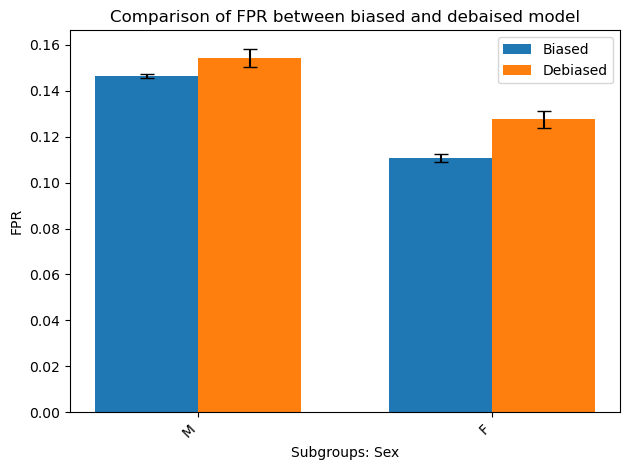

In [24]:
plot_group_metric_errorbars(group_tables, col='Sex', metric='FPR')

In [25]:
metric = "FPR"
col = "Sex"
base_diffs, db_diffs = get_avgs_diffs(group_tables, col, metric)
base_avg_gap = np.average([g[2] for g in base_diffs.values()])
db_avg_gap = np.average([g[2] for g in db_diffs.values()])
print(f"avg gap in avg {metric} between all subgroups of {col} for baseline: {base_avg_gap:0.3f}, debaised: {db_avg_gap:0.3f}")

base_max_gap = max([g[2] for g in base_diffs.values()])
db_max_gap = max([g[2] for g in db_diffs.values()])
print(f"largest gap in avg {metric} between all subgroups of {col} for baseline: {base_max_gap:0.3f}, debaised: {db_max_gap:0.3f}")


avg gap in avg FPR between all subgroups of Sex for baseline: 0.036, debaised: 0.027
largest gap in avg FPR between all subgroups of Sex for baseline: 0.036, debaised: 0.027


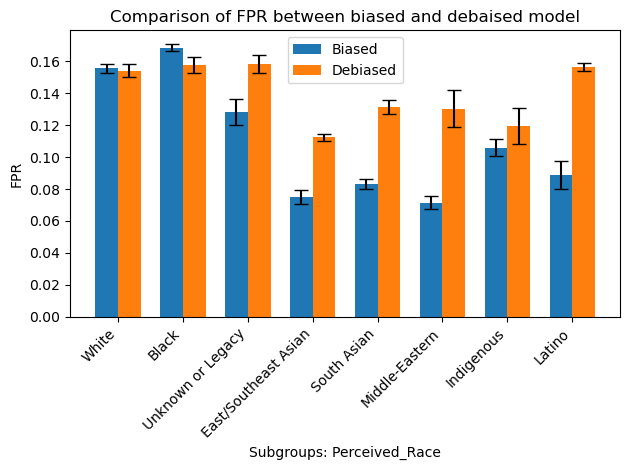

In [26]:
plot_group_metric_errorbars(group_tables, col=protected_cols[0], metric='FPR')

In [27]:
col=protected_cols[0] 
metric='FPR'
base_diffs, db_diffs = get_avgs_diffs(group_tables, col, metric)
base_avg_gap = np.average([g[2] for g in base_diffs.values()])
db_avg_gap = np.average([g[2] for g in db_diffs.values()])
print(f"avg gap in avg {metric} between all subgroups of {col} for baseline: {base_avg_gap:0.3f}, debaised: {db_avg_gap:0.3f}")

base_max_gap = max([g[2] for g in base_diffs.values()])
db_max_gap = max([g[2] for g in db_diffs.values()])
print(f"largest gap in avg {metric} between all subgroups of {col} for baseline: {base_max_gap:0.3f}, debaised: {db_max_gap:0.3f}")


avg gap in avg FPR between all subgroups of Perceived_Race for baseline: 0.044, debaised: 0.022
largest gap in avg FPR between all subgroups of Perceived_Race for baseline: 0.097, debaised: 0.046


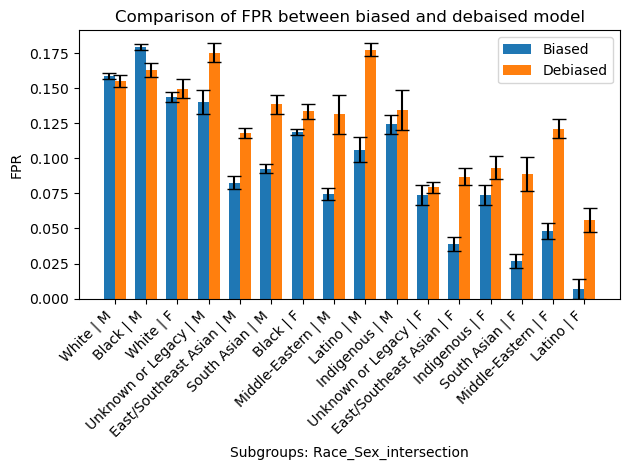

In [32]:
plot_group_metric_errorbars(group_tables, col=protected_cols[2], metric='FPR')

In [33]:
col=protected_cols[2] 
metric='FPR'

base_diffs, db_diffs = get_avgs_diffs(group_tables, col, metric)
base_avg_gap = np.average([g[2] for g in base_diffs.values()])
db_avg_gap = np.average([g[2] for g in db_diffs.values()])
print(f"avg gap in avg {metric} between all subgroups of {col} for baseline: {base_avg_gap:0.3f}, debaised: {db_avg_gap:0.3f}")

base_max_gap = max([g[2] for g in base_diffs.values()])
db_max_gap = max([g[2] for g in db_diffs.values()])
print(f"largest gap in avg {metric} between all subgroups of {col} for baseline: {base_max_gap:0.3f}, debaised: {db_max_gap:0.3f}")


avg gap in avg FPR between all subgroups of Race_Sex_intersection for baseline: 0.058, debaised: 0.042
largest gap in avg FPR between all subgroups of Race_Sex_intersection for baseline: 0.173, debaised: 0.122


## DiCE ML

In [23]:
def get_test_with_pred_class(X_test, y_pred, num_counterfactuals, target_class, target_column):
    # Concat the predicted values to the data for counterfactual generation
    df_predicted = pd.DataFrame(y_pred, columns=[target_column])
    df_test_pred = pd.concat([X_test.reset_index(drop=True), df_predicted.reset_index(drop=True)], axis=1)
    target_set = df_test_pred.loc[df_test_pred[target_column] == target_class].drop([target_column], axis=1)
    if num_counterfactuals is None:
        num_counterfactuals = target_set.shape[0]
        print(f"setting number of counterfactuals to n={num_counterfactuals}")
    elif num_counterfactuals > target_set.shape[0]:
        num_counterfactuals = target_set.shape[0]
        print(f"warning more counterfactuals requested than num datapoints with label, setting n={num_counterfactuals}")
    target_set = target_set.iloc[0:num_counterfactuals,:].reset_index(drop=True)
    return target_set

# Counterfactual generation func from REACT
def produce_cfs(dataset, cf_method, features_to_perturb, max_cfs_per_sample):
    a = []
    for i in range(dataset.shape[0]):
      sample = dataset.iloc[[i]]
      try:
        cf = cf_method.generate_counterfactuals(sample, 
                                                total_CFs=max_cfs_per_sample, 
                                                desired_class="opposite",
                                                posthoc_sparsity_param=0.1,
                                                posthoc_sparsity_algorithm="linear", 
                                                features_to_vary = features_to_perturb,
                                                verbose=False)
        cfs_list = json.loads(cf.to_json()).get('cfs_list')[0]
        a.append(cfs_list)
      except UserConfigValidationException:
        # no counterfactuals found
        print("no counterfactuals found")
        a.append([])
        continue
    return a

def get_feature_type(feature_name):
    categorical_features = ['Perceived_Race', 'Sex', 'Occurrence_Category', 'ArrestLocDiv']
    ordinal_features = ['Age_group__at_arrest_', 'Arrest_Quarter']
    binary_features = ['IsYouth','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']
    if feature_name in categorical_features:
        return "categorical"
    elif feature_name in ordinal_features or binary_features:
        return "ordinal"
    #else:
    #    return "binary"
    
def get_feature_details(df, features_perturb):
    feature_details = {}
    for feature in features_perturb:
            feature_type = get_feature_type(feature)
            
            if feature_type == "numerical":
                min_val, max_val = df[feature].min(), df[feature].max()
                feature_details[feature] = {
                    "type": feature_type,
                    "range_min": min_val,
                    "range_max": max_val
                }

            if feature_type == "ordinal":
                feature_details[feature] = {
                    "type": feature_type,
                    "range_min": df[feature].min(),
                    "range_max": df[feature].max()
                }

            if feature_type == "categorical":
                all_categ_values = sorted(df[feature].unique().tolist())
                feature_details[feature] = {
                    "type": feature_type,
                    "categ_values": all_categ_values
                }
                
            # add binary handling later if needed (currently treating as ordinal with range [0,1])
    return feature_details


In [24]:
# Parameters for counterfacutal testing
max_cfs = 10
max_counterfactuals = 1000 #None
target_class = 0 # want to find samples with this classifiaction to find counterfactual of opposite "desired" class
target_column = 'StripSearch'
features_perturb =  ['ArrestLocDiv','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
min_sup = 0.05 # Minimum support for explanation tables
# explain_features =  ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']
# group cols = explain_features

In [25]:
class NNCaseWrapper:
    def __init__(self, nn_model, preprocessor, scaler, feature_columns, device=DEVICE):
        self.nn_model = nn_model
        self.preprocessor = preprocessor
        self.scaler = scaler
        self.feature_columns = feature_columns
        self.device = device

    def _to_model_features(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=self.feature_columns)

        X_df = X_df[self.feature_columns]
        X_enc = self.preprocessor.transform(X_df)
        if hasattr(X_enc, "toarray"):
            X_enc = X_enc.toarray()
        X_scaled = self.scaler.transform(X_enc).astype(np.float32)
        return X_scaled

    def predict_proba(self, X):
        X_np = self._to_model_features(X)
        with torch.no_grad():
            xb = torch.tensor(X_np, dtype=torch.float32, device=self.device)
            output = self.nn_model(xb)
            if type(output) is tuple: # handle case for multi adv
                output = output[0]
            probs = torch.sigmoid(output).cpu().numpy().reshape(-1, 1)
        return np.hstack([1.0 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [26]:
def gen_counterfactuals_for_case(case, max_cfs, max_counterfactuals, target_class, target_column, features_perturb):
    # Input either a biased or debaised case here, need to have the base case and the model
    # assumes using the X_test split from earlier in the notebook
    # also assumes case is from the pipeline functions above (baseline_case or adv_model)
    # the key is that case[0] is the case setup, case[1] contains the results eval om made, and that case[2] is the model
    name = case[0]['name']
    
    # get the "target set" from the text set with desired classification
    target_set_case = get_test_with_pred_class(
    X_test, case[1][name]['y_pred'], max_counterfactuals, target_class, target_column)

    # wrap the nn for translation between dice and model
    nn_wrapper = NNCaseWrapper(
        nn_model=case[2],
        preprocessor=case[0]['preprocessor'],
        scaler=case[0]['scaler'],
        feature_columns=X_test.columns.tolist(),
        device=DEVICE,
    )

    # let dice rip on it
    d = dice_ml.Data(
        dataframe=pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1),
        continuous_features=[],
        outcome_name=target_column
    )
    m = dice_ml.Model(model=nn_wrapper, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="random")
    cfs_out = produce_cfs(target_set_case, exp, features_perturb, max_cfs)
    target_set_case["cfs_list"] = cfs_out

    # save counterfactuals output to a csv with the name
    cfs_case_path = os.path.join(DICE_DIR, f"{name}.csv")
    target_set_case.to_csv(cfs_case_path, index=False)
    return cfs_case_path


In [135]:
#cfs_filename = gen_counterfactuals_for_case(debiased[0], max_cfs, max_counterfactuals, target_class, target_column, features_perturb)
#cfs_filename

In [136]:
# generate counterfactuals for baseline and debiased models
#baseline_cfs = []
#debiased_cfs = []
#for case in baselines+debiased:
#    print(case[0]['name'])
#    baseline_cfs.append(gen_counterfactuals_for_case(case, max_cfs, max_counterfactuals, target_class, target_column, features_perturb))

### Recourse metrics

In [27]:
def compute_recourse_for_case_cfs(case_cfg_file, group_cols):
    # assumes that you give it a path for a csv file with counterfactuals in it
    # also assumes that you have the train/test split earlier in the notebook
    df = pd.read_csv(case_cfg_file)
    name = case_cfg_file.split(os.sep)[-1][:-4]
    df['cfs_list'] = df['cfs_list'].apply(ast.literal_eval)
    df['cfs_list'] = df['cfs_list'].apply(lambda x: np.array(x))

    def encode_group_cols_for_exp(df_in, ref_df, cols): #Just for post-hoc explanation-table tool compatibility, not a general encoding function.
        out = df_in.copy()
        for c in cols:
            le = LabelEncoder()
            le.fit(ref_df[c].astype(str))  # fit on train/reference
            mapping = {v: i for i, v in enumerate(le.classes_)}
            out[c] = out[c].astype(str).map(mapping).fillna(-1).astype(int)
        return out
    
    #df = df[group_cols + features_perturb + ['cfs_list']]
    selected_features = features_perturb
    feature_details = get_feature_details(df, selected_features)

    # Compute and save recourse metrics for the generated counterfactuals
    r_cost_df = recourse_metrics.recourse_cost_df(df, feature_details, 1)
    r_cost_to_summarize = r_cost_df[group_cols+['recourse_cost']].copy()
    r_cost_to_summarize_enc = encode_group_cols_for_exp(r_cost_to_summarize, X_train, group_cols)
    temp_cost_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_cost_{name}.csv")
    r_cost_to_summarize_enc.to_csv(temp_cost_case_path, index=False)

    r_avail_df = recourse_metrics.recourse_availability_df(df)
    r_avail_df_to_summarize = r_avail_df[group_cols+['recourse_availability']].copy()
    r_avail_df_to_summarize_enc = encode_group_cols_for_exp(r_avail_df_to_summarize, X_train, group_cols)
    temp_avail_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_avail_{name}.csv")
    r_avail_df_to_summarize_enc.to_csv(temp_avail_case_path, index=False)

    r_choice_df = recourse_metrics.recourse_choice_df(df)
    r_choice_df_to_summarize = r_choice_df[group_cols+['recourse_choice']].copy()
    r_choice_df_to_summarize_enc = encode_group_cols_for_exp(r_choice_df_to_summarize, X_train, group_cols)
    temp_choice_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_choice_{name}.csv")
    r_choice_df_to_summarize_enc.to_csv(temp_choice_case_path, index=False)
    return temp_cost_case_path, temp_avail_case_path, temp_choice_case_path

In [138]:
#in_cost_case_path, in_avail_case_path, in_choice_case_path = compute_recourse_for_case_cfs(baseline_cfs[0], group_cols)

In [28]:
def generate_tables_for_case_metric(metric_temp_path, name, min_sup):
    # assumes you have the paths for the metric table for a given case
    # returns the path to the table

    metric = metric_temp_path.split(os.sep)[-1].split('_')[1]
    exp_mod = globals().get("exptb", globals().get("exptbl"))
    if exp_mod is None:
        raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")
    out_table_path = os.path.join(RECOURSE_TABLE_DIR, f"{metric}_table_case_{name}.csv")
    empty_df = pd.DataFrame().to_csv(out_table_path, index=False)
    res = exp_mod.calculate_table(
        out_table_path, metric_temp_path, out_table_path, min_support_param=min_sup
    )
    return res

In [140]:
# Generate counterfactuals for baseline and debiased models
baseline_cfs = []
debiased_cfs = []

for case in baselines:
    name = case[0]['name']
    print(name)
    case_cfs = gen_counterfactuals_for_case(case, max_cfs, max_counterfactuals, target_class, target_column, features_perturb)
    baseline_cfs.append(case_cfs)
    
for case in debiased:
    name = case[0]['name']
    print(name)
    case_cfs = gen_counterfactuals_for_case(case, max_cfs, max_counterfactuals, target_class, target_column, features_perturb)
    debiased_cfs.append(case_cfs)

baseline, seed 1


100%|██████████| 1/1 [00:00<00:00,  5.62it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00,  5.62it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00,  5.05it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00,  5.15it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


In [29]:
baseline_cfs = ['baseline_nn_output\\dice_cf\\baseline, seed 1.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 2.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 3.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 4.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 5.csv']
baseline_cfs

['baseline_nn_output\\dice_cf\\baseline, seed 1.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 2.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 3.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 4.csv',
 'baseline_nn_output\\dice_cf\\baseline, seed 5.csv']

In [30]:
debiased_cfs = ['baseline_nn_output\\dice_cf\\multiadv, seed 1.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 2.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 3.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 4.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 5.csv']
debiased_cfs

['baseline_nn_output\\dice_cf\\multiadv, seed 1.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 2.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 3.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 4.csv',
 'baseline_nn_output\\dice_cf\\multiadv, seed 5.csv']

In [33]:
# Generate Explanation tables for comparison
baseline_tables = {'cost':[], 'availability':[], 'choice':[]}
debiased_tables = {'cost':[], 'availability':[], 'choice':[]}


for i,case in enumerate(baselines):
    case_cfs = baseline_cfs[i]
    name = name = case[0]['name']
    in_cost_case_path, in_avail_case_path, in_choice_case_path = compute_recourse_for_case_cfs(case_cfs, group_cols)
    baseline_tables['cost'].append(generate_tables_for_case_metric(in_cost_case_path,name,min_sup))
    baseline_tables['availability'].append(generate_tables_for_case_metric(in_avail_case_path,name,min_sup))
    baseline_tables['choice'].append(generate_tables_for_case_metric(in_choice_case_path,name,min_sup))

for i,case in enumerate(debiased):
    case_cfs = debiased_cfs[i]
    name = name = case[0]['name']
    in_cost_case_path, in_avail_case_path, in_choice_case_path = compute_recourse_for_case_cfs(case_cfs, group_cols)
    debiased_tables['cost'].append(generate_tables_for_case_metric(in_cost_case_path,name,min_sup))
    debiased_tables['availability'].append(generate_tables_for_case_metric(in_avail_case_path,name,min_sup))
    debiased_tables['choice'].append(generate_tables_for_case_metric(in_choice_case_path,name,min_sup))


Compiling with commands:  ['g++', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Explanations.cpp', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Lighthouse.cpp', '-o', 'program']
Arguments to the program: baseline_nn_output\recourse_tables\cost_table_case_baseline, seed 1.csv baseline_nn_output\recourse_temp\temp_cost_baseline, seed 1.csv 3 15 0 baseline_nn_output\recourse_tables\cost_table_case_baseline, seed 1.csv 0.05
Time: 0:00:05.486541
Compiling with commands:  ['g++', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Explanations.cpp', 'c:\\Users\\Andrew\\Documents\\School\\6320 AI Fairness\\groupproject\\exp\\Lighthouse.cpp', '-o', 'program']
Arguments to the program: baseline_nn_output\recourse_tables\avail_table_case_baseline, seed 1.csv baseline_nn_output\recourse_temp\temp_avail_baseline, seed 1.csv 3 15 0 baseline_nn_output\recourse_tables\avail_table_case_baseline, seed 1.csv 0.05
Time: 

In [34]:
baseline_tables

{'cost': ['baseline_nn_output\\recourse_tables\\cost_table_case_baseline, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_baseline, seed 2.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_baseline, seed 3.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_baseline, seed 4.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_baseline, seed 5.csv'],
 'availability': ['baseline_nn_output\\recourse_tables\\avail_table_case_baseline, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_baseline, seed 2.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_baseline, seed 3.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_baseline, seed 4.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_baseline, seed 5.csv'],
 'choice': ['baseline_nn_output\\recourse_tables\\choice_table_case_baseline, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\choice_table_case_baseline, seed 2.csv',
  'base

In [35]:
debiased_tables

{'cost': ['baseline_nn_output\\recourse_tables\\cost_table_case_multiadv, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_multiadv, seed 2.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_multiadv, seed 3.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_multiadv, seed 4.csv',
  'baseline_nn_output\\recourse_tables\\cost_table_case_multiadv, seed 5.csv'],
 'availability': ['baseline_nn_output\\recourse_tables\\avail_table_case_multiadv, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_multiadv, seed 2.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_multiadv, seed 3.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_multiadv, seed 4.csv',
  'baseline_nn_output\\recourse_tables\\avail_table_case_multiadv, seed 5.csv'],
 'choice': ['baseline_nn_output\\recourse_tables\\choice_table_case_multiadv, seed 1.csv',
  'baseline_nn_output\\recourse_tables\\choice_table_case_multiadv, seed 2.csv',
  'base

In [39]:
pd.read_csv(baseline_tables['cost'][0], sep=";")

,Perceived_Race,Sex,Age_group__at_arrest_,recourse_cost,support
0,*,*,*,0.934,670
1,*,*,3,0.983,174
2,5,*,*,1.235,34
3,7,*,*,0.954,305
4,*,*,2,0.950,222
5,0,*,*,0.940,168
6,0,*,2,1.017,58
7,*,0,3,1.050,40
8,1,*,*,0.943,35
9,7,1,*,0.948,233


In [80]:
unique_rules = {'cost': [], 'availability': [], 'choice': []}
for metric in unique_rules:
    for tab in baseline_tables[metric]:
        table = pd.read_csv(tab, sep = ";")
        for i in range(1,6):
        #print(tuple(table.iloc[i,0:3].to_list()), table.iloc[i,3])
            rule = tuple(table.iloc[i,0:3].to_list())
            if rule not in unique_rules[metric]:
                unique_rules[metric].append(rule)
    print(metric, len(unique_rules[metric]))


cost 17
availability 13
choice 14


In [ ]:
in_cost_case_path, in_avail_case_path, in_choice_case_path = compute_recourse_for_case_cfs(baseline_cfs[0], group_cols)


In [65]:
df_cost = pd.read_csv(in_cost_case_path, sep=",")

In [86]:
def get_rule_values(cfg_paths, unique_rules):
    rule_vals =  {'cost': defaultdict(list), 'availability': defaultdict(list), 'choice': defaultdict(list)}

    # for every set of counterfactuals for each model 
    for case_cfs in cfg_paths:
        # compute their cost metrics
        in_cost_case_path, in_avail_case_path, in_choice_case_path = compute_recourse_for_case_cfs(case_cfs, group_cols)
        # then for each metric type
        for metric in unique_rules:
            if metric == 'cost':
                df = pd.read_csv(in_cost_case_path, sep=",")
            if metric == 'availability':
                df = pd.read_csv(in_avail_case_path, sep=",")
            if metric == 'choice':
                df = pd.read_csv(in_choice_case_path, sep=",")
            # get the aggregation for each unique rule that we care about
            #print(metric)
            for rule in unique_rules[metric]:
                df_filtered = df.copy()
                for i,col in enumerate(group_cols):    
                    if rule[i] != "*":
                        df_filtered = df_filtered[df_filtered[col] == int(rule[i])]
                rule_vals[metric][rule].append((np.average(df_filtered[df_filtered.columns[-1]]), df_filtered.shape[0]))
                #print(rule,np.average(df_filtered[df_filtered.columns[-1]]), df_filtered.shape[0])
    return rule_vals


In [ ]:
baseline_rule_vals = get_rule_values(baseline_cfs, unique_rules)
debiased_rule_vals = get_rule_values(debiased_cfs, unique_rules)

In [89]:
debiased_rule_vals['cost']

defaultdict(list,
            {('*', '*', '3'): [(0.9483568075117371, 213),
              (0.8737373737373737, 198),
              (0.9375, 160),
              (0.9128440366972477, 218),
              (0.8923076923076924, 195)],
             ('5', '*', '*'): [(0.7872340425531915, 47),
              (0.8604651162790697, 43),
              (1.0, 36),
              (1.0476190476190477, 42),
              (0.875, 48)],
             ('7', '*', '*'): [(0.96996996996997, 333),
              (0.9106628242074928, 347),
              (0.9131944444444444, 288),
              (0.9466292134831461, 356),
              (0.8830769230769231, 325)],
             ('*', '*', '2'): [(0.9183673469387755, 245),
              (0.8458498023715415, 253),
              (0.9205020920502092, 239),
              (0.9034749034749034, 259),
              (0.8607594936708861, 237)],
             ('0', '*', '*'): [(0.9824561403508771, 228),
              (0.8969072164948454, 194),
              (0.9701492537313433, 201

In [108]:
def plot_cfs_metric_comp(baseline_rule_vals, debiased_rule_vals, metric = 'cost', col='Race, Sex, Age Group'):
    # plotting barchart with standard error of the mean error bars

    # gross little nested comp that is just turning the internal list of tuples of (metric, support) into a list of metric vals
    # this is the part that would need to be changed to work with diff data, really just need a dict keyed by groups and sublists of values
    group_metrics_baseline = {k:[v[0] for v in baseline_rule_vals[metric][k]] for k in baseline_rule_vals[metric]}
    group_metrics_debiased = {k:[v[0] for v in debiased_rule_vals[metric][k]] for k in debiased_rule_vals[metric]}
    subgroups = list(group_metrics_baseline.keys())
    x = np.arange(len(subgroups))
    width = 0.35

    def mean_and_sem(data_dict):
        means = []
        sems = []
        for key in subgroups:
            values = data_dict[key]
            mean = np.mean(values)
            sem = np.std(values, ddof=1) / np.sqrt(len(values))
            means.append(mean)
            sems.append(sem)
        return means, sems

    means1, sem1 = mean_and_sem(group_metrics_baseline)
    means2, sem2 = mean_and_sem(group_metrics_debiased)

    fig, ax = plt.subplots()

    ax.bar(x - width/2, means1, width, yerr=sem1, capsize=5, label="Biased")
    ax.bar(x + width/2, means2, width, yerr=sem2, capsize=5, label="Debiased")

    # Formatting
    ax.set_xlabel(f"Subgroups: {col}")
    ax.set_ylabel(f"{metric}")
    ax.set_title(f"Comparison of {metric} between biased and debaised model")
    ax.set_xticks(x)
    ax.set_xticklabels(subgroups, rotation=45, ha='right')
    ax.legend()

    
    # for gettting the averages
    
    base_avg = np.average([item for sublist in group_metrics_baseline.values() for item in sublist])
    deb_avg = np.average([item for sublist in group_metrics_debiased.values() for item in sublist])
    print(f"avg {metric} across all reported subgroups baseline: {base_avg:0.3f}, debiased: {deb_avg:0.3f}")
    subgroups = list(group_metrics_baseline.keys())
    base_sgms = {}
    db_sgms = {}
    for s in subgroups:
        base_sgms[s] = np.mean(group_metrics_baseline[s])
        db_sgms[s] = np.mean(group_metrics_debiased[s])
    base_diffs = {}
    db_diffs = {}
    for s in combinations(subgroups,2):
        base_diffs[s] = base_sgms[s[0]], base_sgms[s[1]], abs(base_sgms[s[0]]-base_sgms[s[1]])
        db_diffs[s] = db_sgms[s[0]], db_sgms[s[1]], abs(db_sgms[s[0]]-db_sgms[s[1]])
    
    base_avg_gap = np.average([g[2] for g in base_diffs.values()])
    db_avg_gap = np.average([g[2] for g in db_diffs.values()])
    print(f"avg gap in avg {metric} between all subgroups of {col} for baseline: {base_avg_gap:0.3f}, debaised: {db_avg_gap:0.3f}")

    base_max_gap = max([g[2] for g in base_diffs.values()])
    db_max_gap = max([g[2] for g in db_diffs.values()])
    print(f"largest gap in avg {metric} between all subgroups of {col} for baseline: {base_max_gap:0.3f}, debaised: {db_max_gap:0.3f}")


    plt.tight_layout()
    plt.show()

avg cost across all reported subgroups baseline: 0.933, debiased: 0.926
avg gap in avg cost between all subgroups of Race, Sex, Age Group for baseline: 0.028, debaised: 0.043
largest gap in avg cost between all subgroups of Race, Sex, Age Group for baseline: 0.082, debaised: 0.119


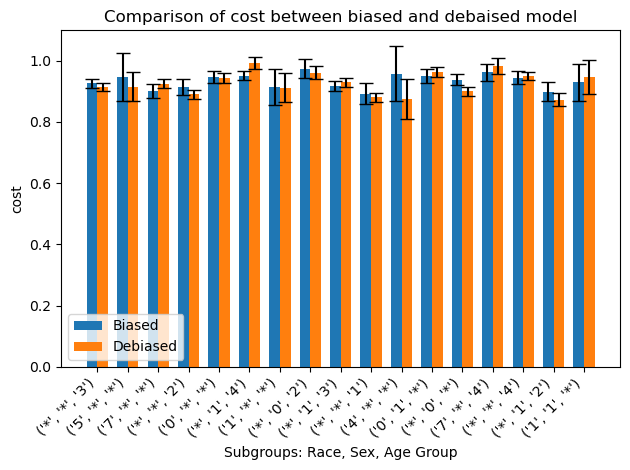

In [109]:
plot_cfs_metric_comp(baseline_rule_vals, debiased_rule_vals, metric='cost')

avg availability across all reported subgroups baseline: 0.741, debiased: 0.796
avg gap in avg availability between all subgroups of Race, Sex, Age Group for baseline: 0.034, debaised: 0.041
largest gap in avg availability between all subgroups of Race, Sex, Age Group for baseline: 0.132, debaised: 0.141


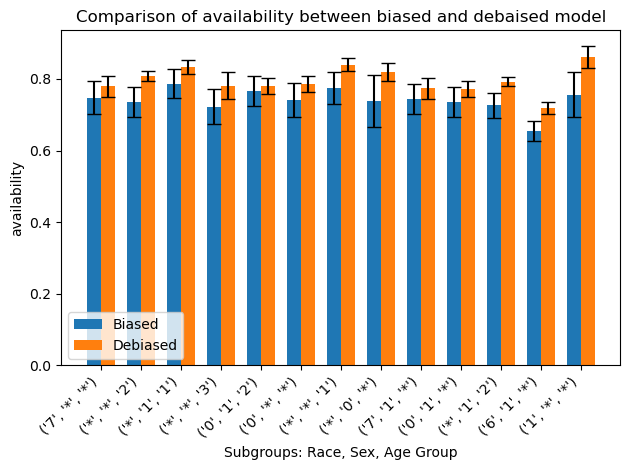

In [110]:
plot_cfs_metric_comp(baseline_rule_vals, debiased_rule_vals, metric='availability')

avg choice across all reported subgroups baseline: 6.654, debiased: 7.454
avg gap in avg choice between all subgroups of Race, Sex, Age Group for baseline: 0.372, debaised: 0.490
largest gap in avg choice between all subgroups of Race, Sex, Age Group for baseline: 1.132, debaised: 1.491


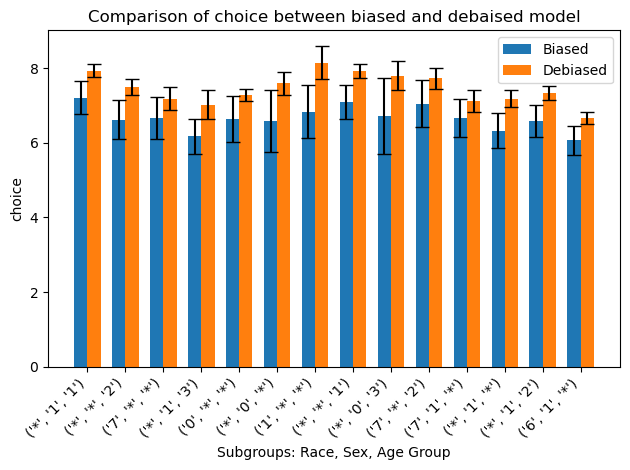

In [111]:
plot_cfs_metric_comp(baseline_rule_vals, debiased_rule_vals, metric='choice')